# RE/MAX Türkiye Case Study
### Başlarken

Kullanılan tüm SQL sorguları "sql" klasörüne kaydedilmiştir. Oluşturulan sorgulara ait her bir sorgu dosyasının içinde sorgunun kısa açıklaması yorum satırı olarak verilmiştir. Veriyi daha iyi incelemek adına görselleştirmeler uygulanacaktır.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "case_study")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "postgres")

engine = create_engine(
    f"postgresql+psycopg://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)


# Ofis Performansı
1. ### Ofis Bazında Toplam İşlem Sayısı

In [2]:

sql_file_path = "sql/Ofis_Performansi/Ofis_toplam_islem.sql"  # .sql sorgu dosyanızın yolu

with open(sql_file_path, "r", encoding="utf-8") as f:
    sql_query = f.read()

df = pd.read_sql(sql_query, engine)


df.head(20)

,id,ad,toplam_islem_sayisi
0,22,REMAX Ofis 22,35
1,19,REMAX Ofis 19,35
2,2,REMAX Ofis 2,35
3,49,REMAX Ofis 49,34
4,29,REMAX Ofis 29,34
5,3,REMAX Ofis 3,34
6,7,REMAX Ofis 7,34
7,39,REMAX Ofis 39,34
8,12,REMAX Ofis 12,34
9,14,REMAX Ofis 14,33


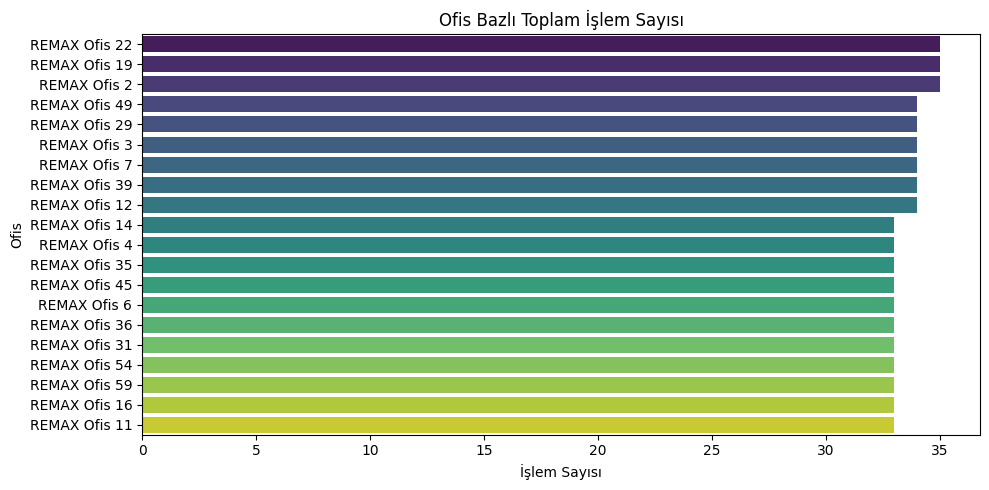

In [3]:

plt.figure(figsize=(10, 5))
sns.barplot(data=df.head(20), x="toplam_islem_sayisi", y="ad", hue="ad", palette="viridis", legend=False)
plt.ylabel("Ofis")
plt.xlabel("İşlem Sayısı")
plt.title("Ofis Bazlı Toplam İşlem Sayısı")
plt.tight_layout()
plt.show()

2. ### Ofis Bazında Toplam Ciro

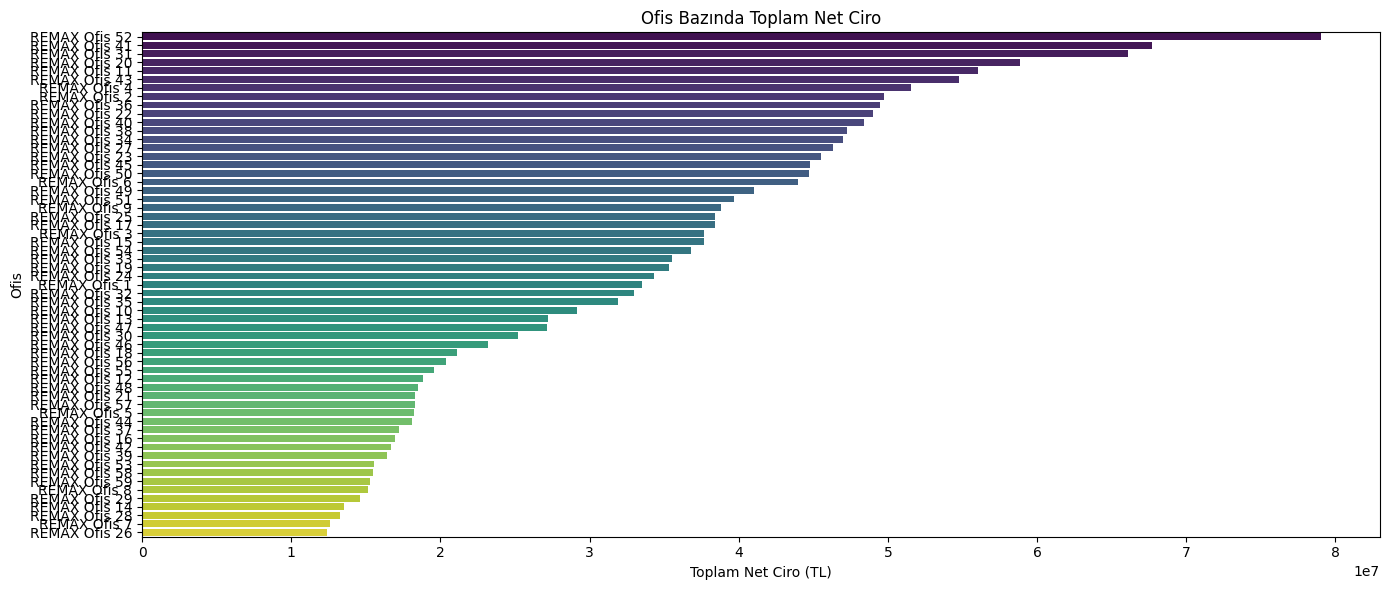

In [4]:
with open("sql/Ofis_Performansi/Ofis_Toplam_Ciro.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ofis_ciro = pd.read_sql(query, engine)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_ofis_ciro, x="toplam_net_ciro_tl", y="ad", hue="ad", palette="viridis", legend=False)
plt.xlabel("Toplam Net Ciro (TL)")
plt.ylabel("Ofis")
plt.title("Ofis Bazında Toplam Net Ciro")
plt.tight_layout()
plt.show()

**Yorum:** Ofisler arasında toplam net ciro açısından belirgin farklar gözlemlenmektedir. İşlem sayılarının birbirine yakın olmasına rağmen (31-35 arası) ciro farklarının bu denli açık olması, ofislerin faaliyet gösterdiği bölgelerdeki mülk değerlerinin, komisyon oranlarının ve işlem tiplerinin (satış/kiralama) farklılığına işaret etmektedir. Yüksek cirolu ofisler genellikle yüksek değerli gayrimenkul bölgelerinde konumlanmış olabilir.

3. ### Ofis Bazında Ortalama İşlem Tutarı

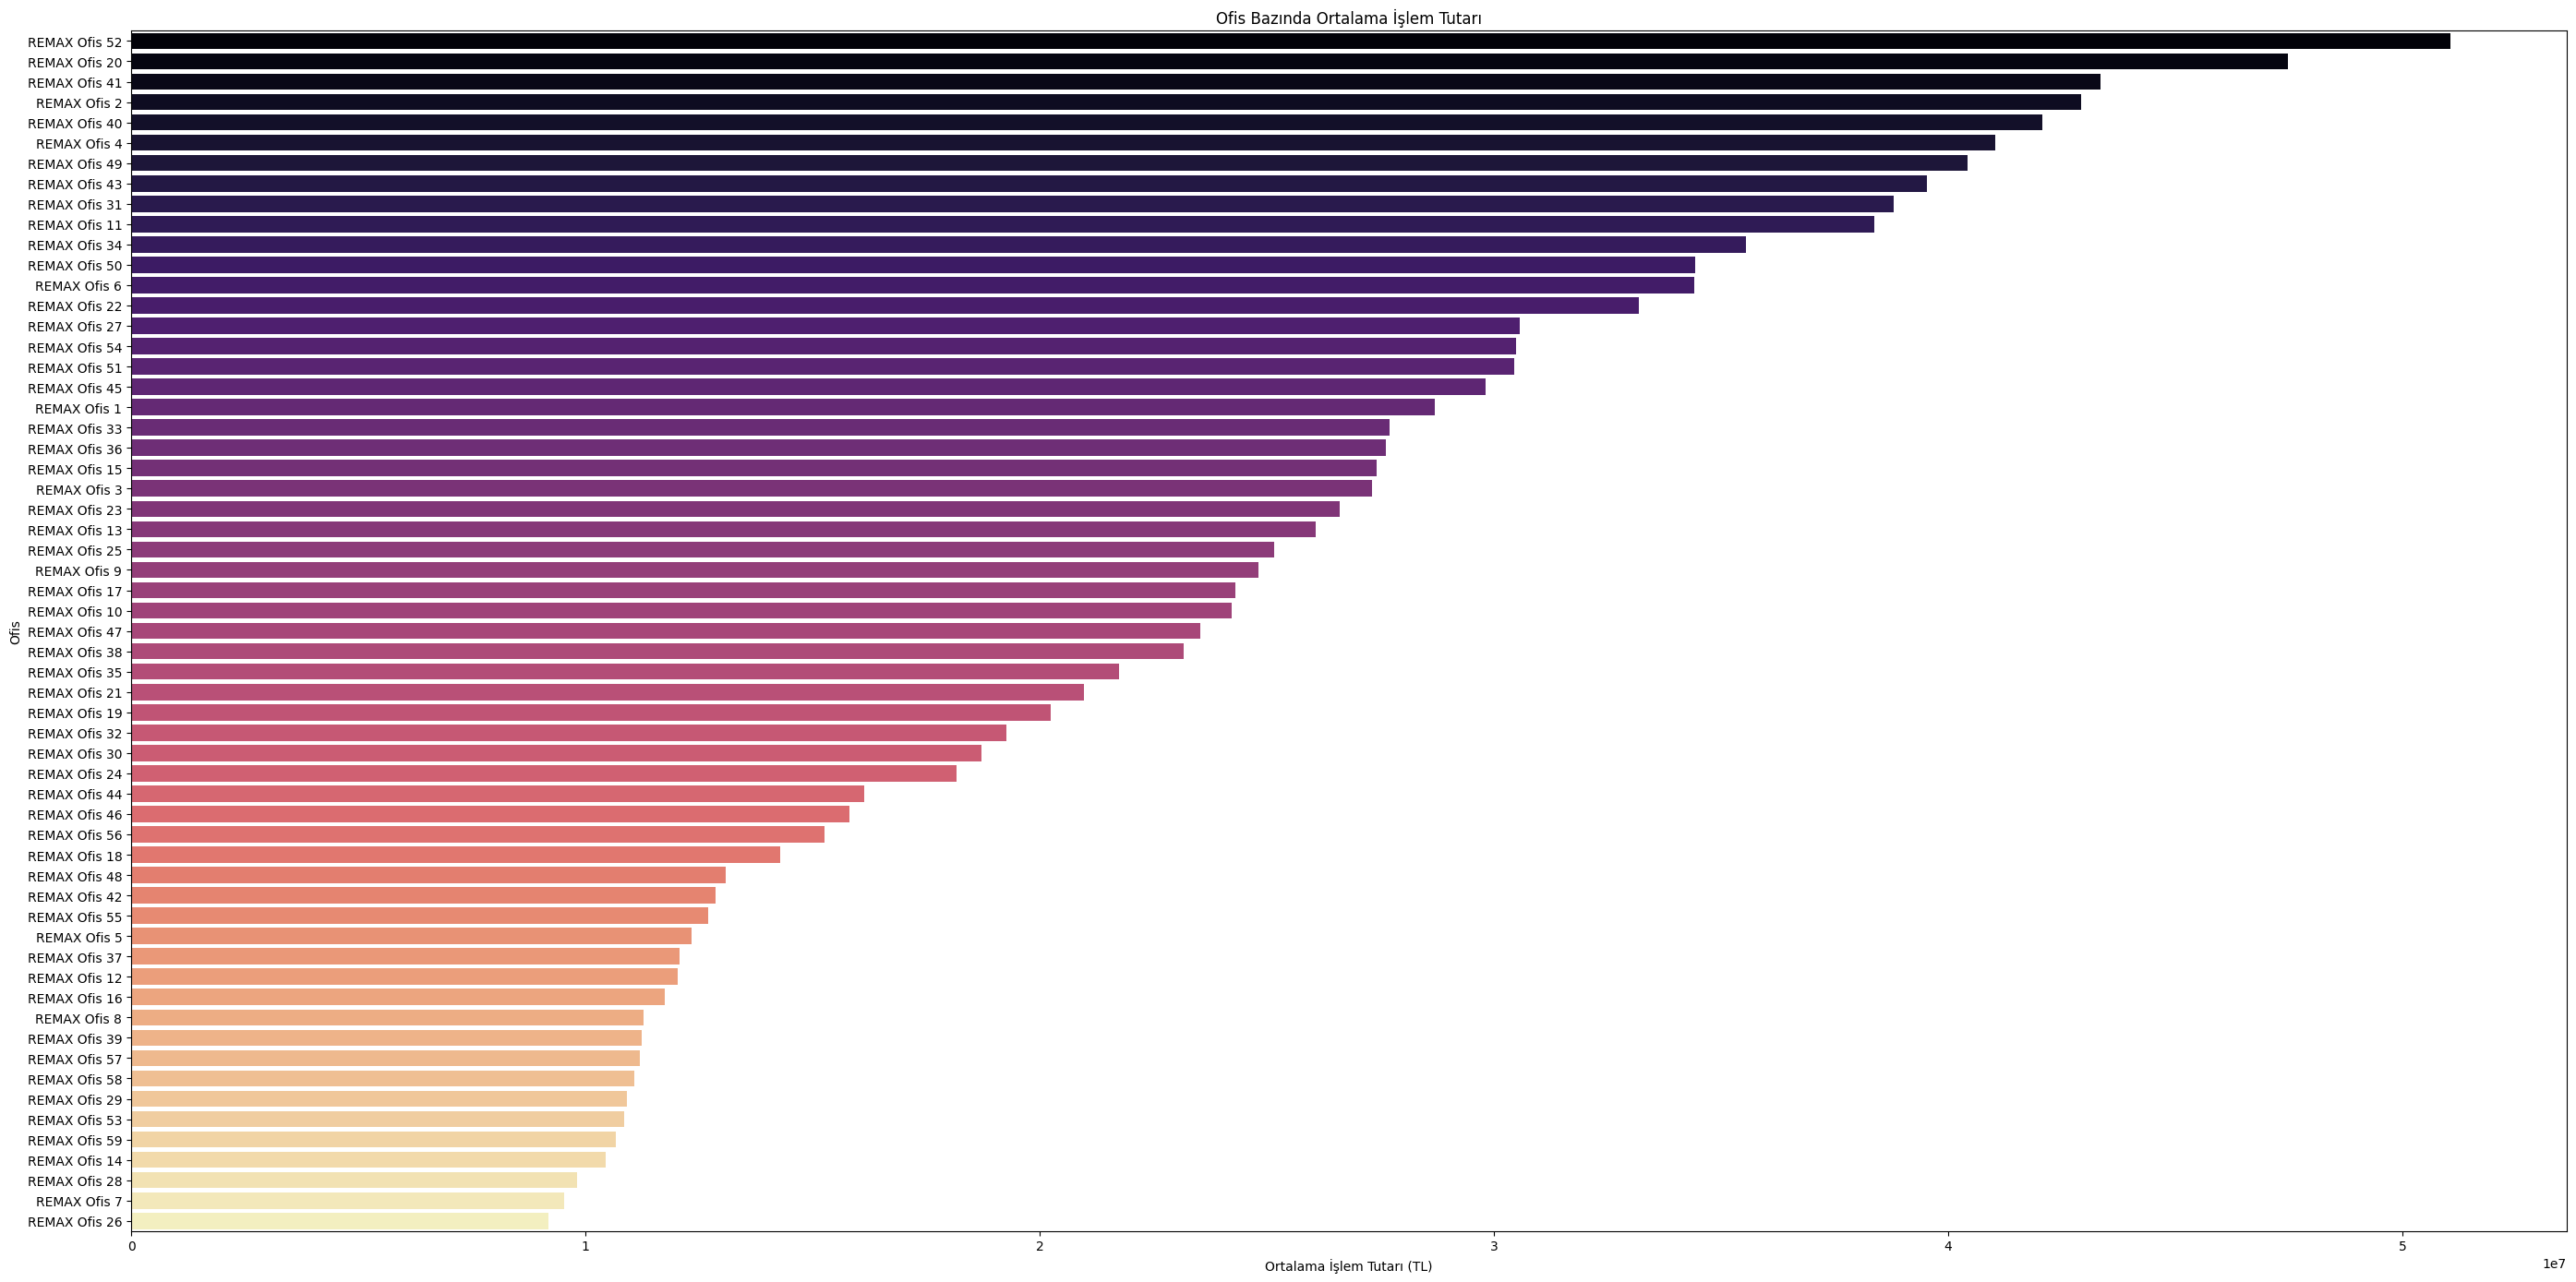

In [5]:
with open("sql/Ofis_Performansi/Ofis_Ortalama_Islem_Tutari.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ofis_ort = pd.read_sql(query, engine)

plt.figure(figsize=(28, 14))
sns.barplot(data=df_ofis_ort, x="ortalama_islem_tutari_tl", y="ad", hue="ad", palette="magma", legend=False)
plt.xlabel("Ortalama İşlem Tutarı (TL)")
plt.ylabel("Ofis")
plt.title("Ofis Bazında Ortalama İşlem Tutarı")
plt.tight_layout()
plt.show()

**Yorum:** Ofislerin ortalama işlem tutarları arasında belirgin farklılıklar dikkat çekmektedir. Bu durum, bazı ofislerin daha yüksek değerli mülklerle çalıştığını göstermektedir. Toplam ciro ile karşılaştırıldığında, yüksek ortalama tutarlı ofisler mutlaka en yüksek toplam ciroyu yapmayabilir; zira toplam ciro hem işlem sayısı hem de işlem büyüklüğüne bağlıdır.

# Çalışan Performansı
1. ### Çalışan Bazında Toplam İşlem Sayısı

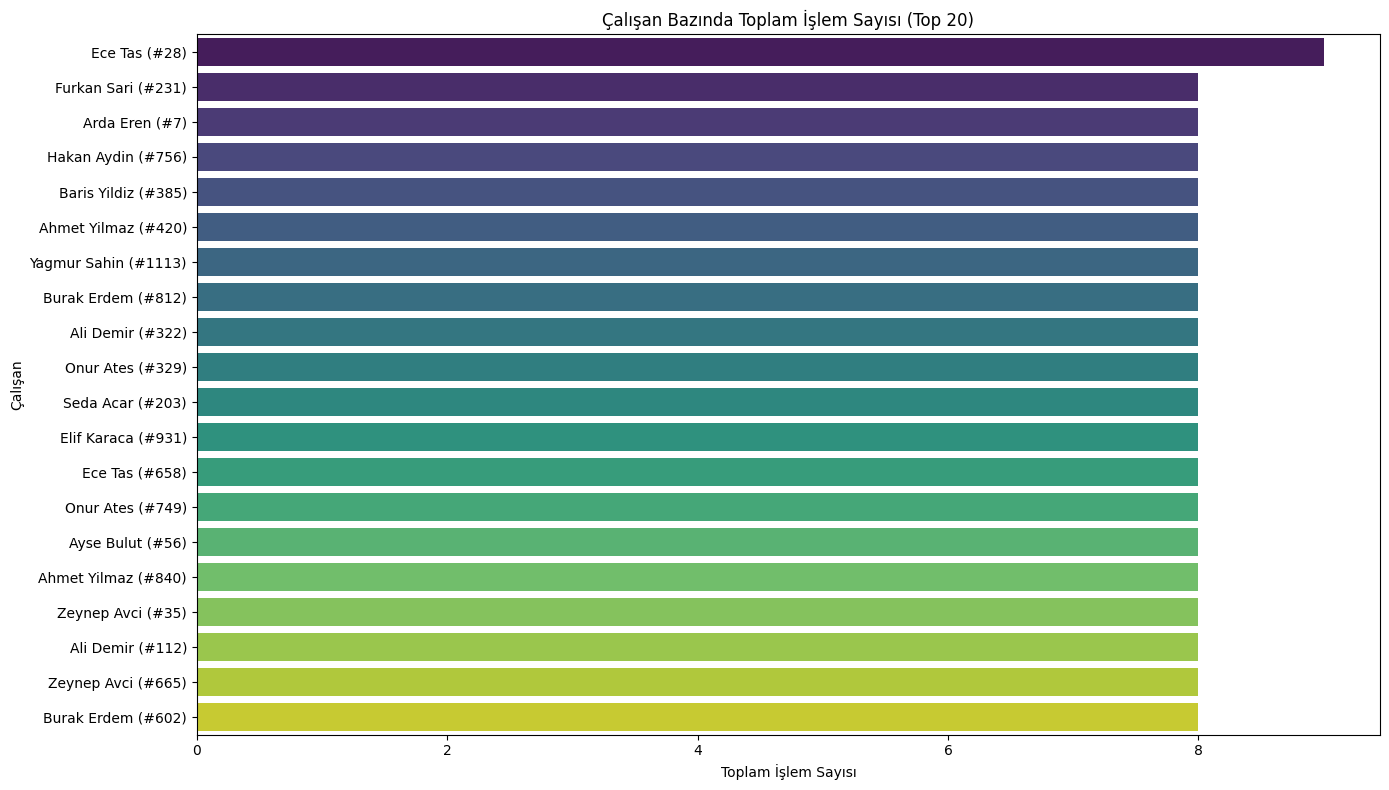

In [6]:
with open("sql/Calisan_Performansi/Calisan_toplam_islem.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_cal_islem = pd.read_sql(query, engine)
df_cal_islem["ad_soyad"] = df_cal_islem["ad"] + " " + df_cal_islem["soyad"] + " (#" + df_cal_islem["id"].astype(str) + ")"

plt.figure(figsize=(14, 8))
top20 = df_cal_islem.head(20)
sns.barplot(data=top20, x="toplam_islem_sayisi", y="ad_soyad", hue="ad_soyad", palette="viridis", legend=False)
plt.xlabel("Toplam İşlem Sayısı")
plt.ylabel("Çalışan")
plt.title("Çalışan Bazında Toplam İşlem Sayısı (Top 20)")
plt.tight_layout()
plt.show()

**Yorum:** Top 20 çalışanın işlem sayıları incelendiğinde, bireysel performansların ofis bazlı dağılıma kıyasla daha heterojen bir yapı gösterdiği dikkat çekmektedir. Yüksek işlem sayısına sahip çalışanlar, aktif sahada çalışan danışmanlar olup verimlilik açısından rol model niteliğindedir.

2. ### Çalışan Bazında Toplam Ciro

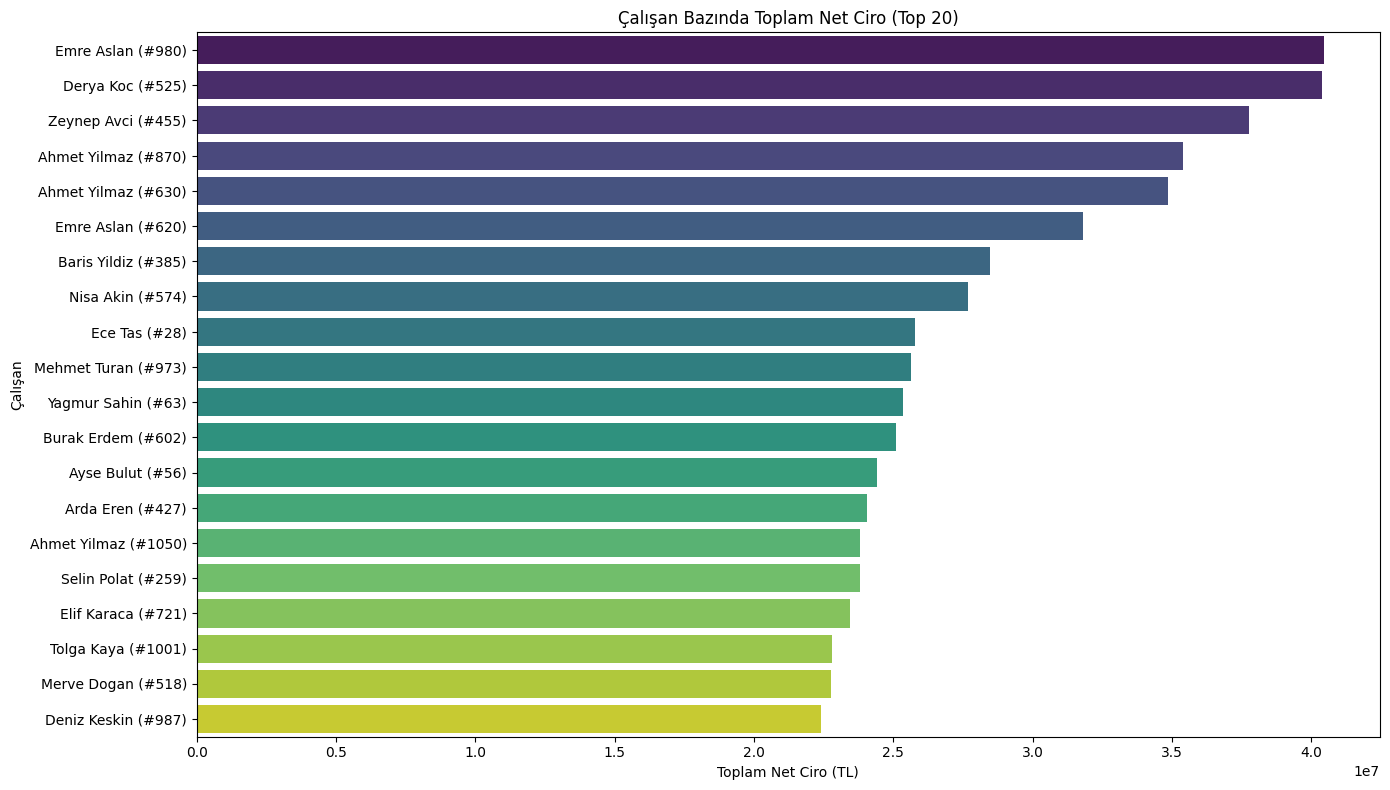

In [7]:
with open("sql/Calisan_Performansi/Calisan_Toplam_Ciro.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_cal_ciro = pd.read_sql(query, engine)
df_cal_ciro["ad_soyad"] = df_cal_ciro["ad"] + " " + df_cal_ciro["soyad"] + " (#" + df_cal_ciro["id"].astype(str) + ")"

plt.figure(figsize=(14, 8))
top20 = df_cal_ciro.head(20)
sns.barplot(data=top20, x="toplam_net_ciro_tl", y="ad_soyad", hue="ad_soyad", palette="viridis", legend=False)
plt.xlabel("Toplam Net Ciro (TL)")
plt.ylabel("Çalışan")
plt.title("Çalışan Bazında Toplam Net Ciro (Top 20)")
plt.tight_layout()
plt.show()

**Yorum:** Çalışanların toplam net ciroları arasında ciddi farklılıklar bulunmaktadır. En yüksek ciro yapan çalışan ile listenin alt sıralarındaki arasındaki fark, bireysel performans ve işlem büyüklüğündeki farklılığı yansıtmaktadır. Net ciro hesaplamasında referral (%20 kesinti) ve cooperation (%50 kesinti) komisyonları dikkate alınmaktadır.

3. ### Çalışan Bazında Ortalama İşlem Tutarı

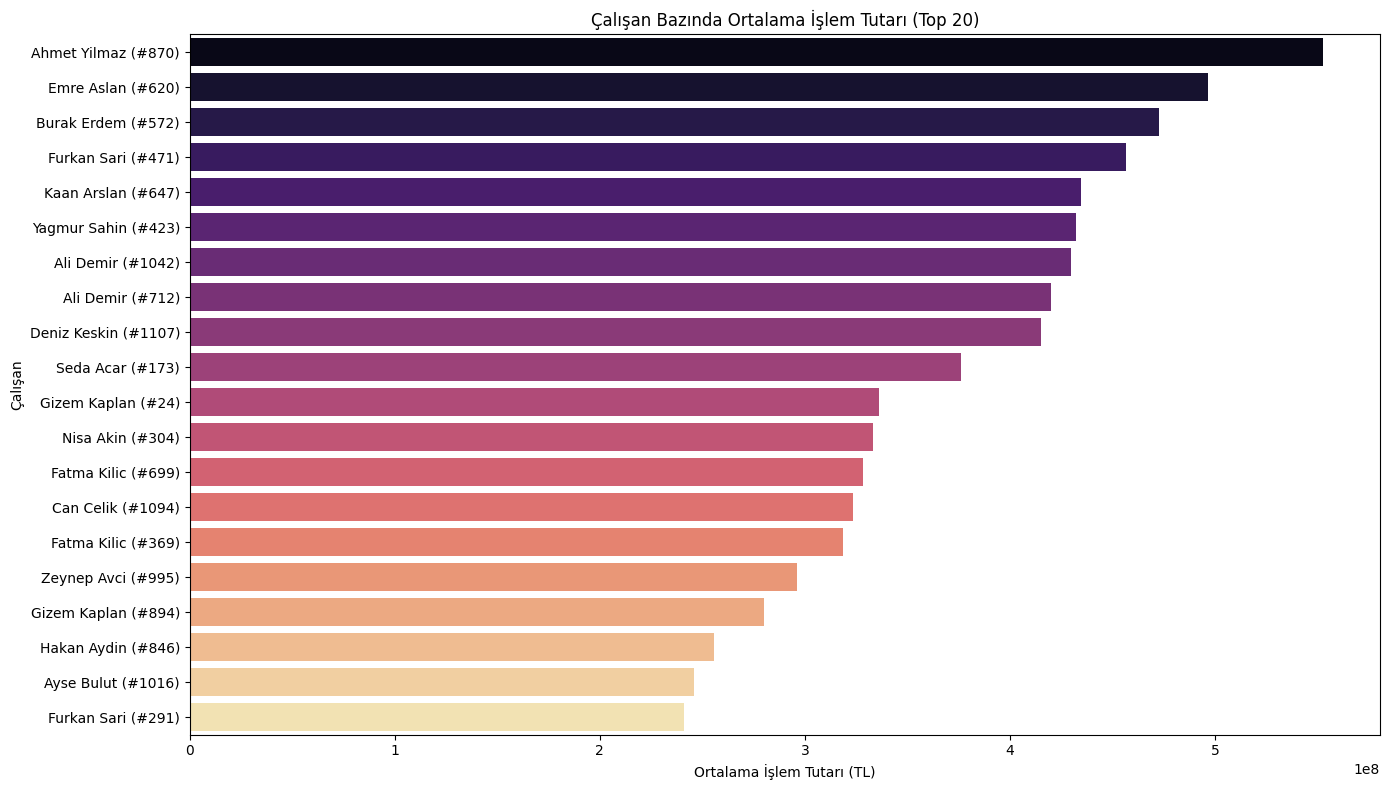

In [8]:
with open("sql/Calisan_Performansi/Calisan_Ortalama_Islem_Tutari.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_cal_ort = pd.read_sql(query, engine)
df_cal_ort["ad_soyad"] = df_cal_ort["ad"] + " " + df_cal_ort["soyad"] + " (#" + df_cal_ort["id"].astype(str) + ")"

plt.figure(figsize=(14, 8))
top20 = df_cal_ort.head(20)
sns.barplot(data=top20, x="ortalama_islem_tutari_tl", y="ad_soyad", hue="ad_soyad", palette="magma", legend=False)
plt.xlabel("Ortalama İşlem Tutarı (TL)")
plt.ylabel("Çalışan")
plt.title("Çalışan Bazında Ortalama İşlem Tutarı (Top 20)")
plt.tight_layout()
plt.show()

**Yorum:** Ortalama işlem tutarı yüksek olan çalışanlar, yüksek değerli mülklere odaklanma eğiliminde olabilir. Bu metrik, toplam ciro ile birlikte değerlendirildiğinde, çalışanların portföy stratejileri hakkında önemli ipuçları verir: Az sayıda yüksek değerli işlem mi yoksa çok sayıda düşük değerli işlem mi yapıyorlar?

4. ### Çalışan Lead → Randevu Dönüşüm Oranı

In [9]:
with open("sql/Calisan_Performansi/calisan_lead_randevu_orani___.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_cal_lead = pd.read_sql(query, engine)
df_cal_lead.head(20)



,id,eposta,calisan_adi,toplam_lead,randevuya_donen_lead,randevu_orani_yuzde
0,782,calisan782@ornek.com,Burak Erdem,11,0,0.0
1,31,calisan31@ornek.com,Elif Karaca,11,0,0.0
2,978,calisan978@ornek.com,Murat Bozkurt,10,0,0.0
3,299,calisan299@ornek.com,Onur Ates,11,0,0.0
4,867,calisan867@ornek.com,Deniz Keskin,10,0,0.0
5,801,calisan801@ornek.com,Furkan Sari,10,0,0.0
6,561,calisan561@ornek.com,Furkan Sari,11,0,0.0
7,239,calisan239@ornek.com,Onur Ates,11,0,0.0
8,266,calisan266@ornek.com,Ayse Bulut,11,0,0.0
9,131,calisan131@ornek.com,Tolga Kaya,11,0,0.0


**Yorum — Operasyonel Problem Tespiti:** Lead-randevu dönüşüm oranları incelendiğinde dikkat çekici bir tablo ortaya çıkmaktadır: Çalışanların büyük çoğunluğu (%80, 896 kişi) **%0** dönüşüm oranına sahipken, geri kalan %20'si (224 kişi) **%100** dönüşüm oranına sahiptir. Ara değerlerin hiç olmaması ciddi bir anomalidir. Bu verideki amaç, hangi çalışanların daha düşük veya yüksek  lead/randevu oranı olduğu görebilmektir.

**Veri kalitesi notu:** Case Study dokümanında veri setinin kasıtlı olarak eksik değerler, aykırı değerler ve veri tutarsızlıkları içerdiği belirtilmiştir. Bu tamamen ikili (binary) dağılım, kasıtlı olarak bırakılmış bir **operasyonel istisna** veya **veri tutarsızlığı** olabilir. Lead'lerin ya tamamen işlendiği ya da hiç dokunulmadığı anlamına gelmektedir; bu durum yönetimin "lead'ler doğru yönetilmiyor olabilir" şüphesini doğrulamaktadır. Lead dağıtım algoritması ve takip süreçlerinin acilen gözden geçirilmesi gerekmektedir.

# Lead Analizi
1. ### Lead Funnel Analizi

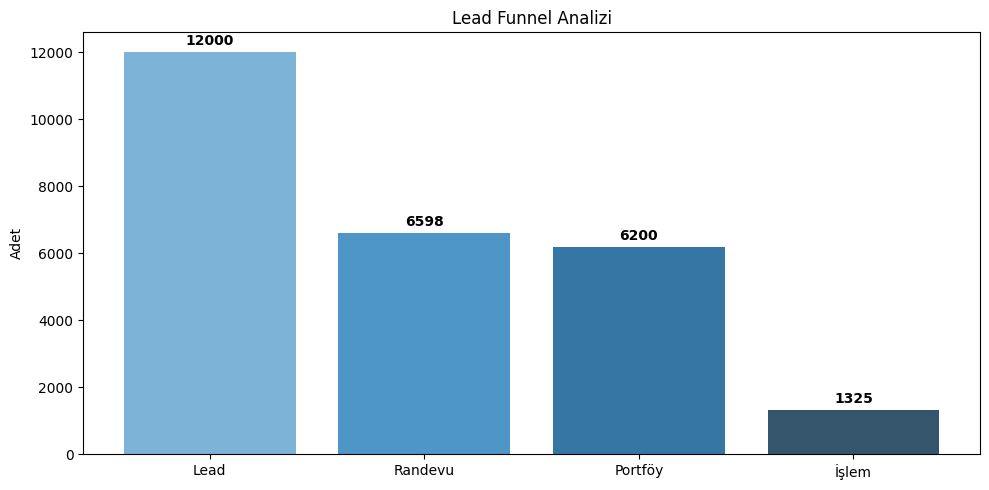

Lead → Randevu: %54.98
Randevu → Portföy: %93.97
Portföy → İşlem: %21.37


In [10]:
with open("sql/Lead_Analizi/Lead_Analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_funnel = pd.read_sql(query, engine)

stages = ["lead_sayisi", "randevu_sayisi", "portfoy_sayisi", "islem_sayisi"]
labels = ["Lead", "Randevu", "Portföy", "İşlem"]
values = [float(df_funnel[col].iloc[0]) for col in stages]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, values, color=sns.color_palette("Blues_d", len(labels)))
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01,
             f"{int(val)}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("Adet")
plt.title("Lead Funnel Analizi")
plt.tight_layout()
plt.show()

print(f"Lead → Randevu: %{df_funnel['lead_to_randevu'].iloc[0]}")
print(f"Randevu → Portföy: %{df_funnel['randevu_to_portfoy'].iloc[0]}")
print(f"Portföy → İşlem: %{df_funnel['portfoy_to_islem'].iloc[0]}")

**Yorum — Operasyonel Problem Tespiti:** Lead funnel analizi kritik darboğazları ortaya koymaktadır:
- **Lead → Randevu:** %54.98 — Lead'lerin yaklaşık yarısı randevuya dönüşmektedir. Bu, yönetimin "lead'ler doğru yönetilmiyor olabilir" şüphesiyle uyumludur.
- **Randevu → Portföy:** %93.97 — Randevu alınan lead'lerin neredeyse tamamı portföye dönüşmektedir. Bu aşama çok verimli çalışmaktadır.
- **Portföy → İşlem:** %21.37 — **En kritik kayıp noktası burasıdır.** Portföye alınan mülklerin yaklaşık 5'te 4'ü işleme dönüşememektedir. Bu durum, yönetimin "portföy kalitesi düşük olabilir" şüphesini doğrulamaktadır.

**Veri kalitesi notu:** Veri setinde kasıtlı olarak bırakılan aykırı değerler ve operasyonel istisnalar funnel dönüşüm oranlarını etkileyebilir. Analizlerde `islem_durumu='tamamlandi'` filtresi uygulanmıştır; iptal edilen işlemler hariç tutulmuştur.

2. ### Hiç İşlenmeyen Lead Oranı (1. Problem)

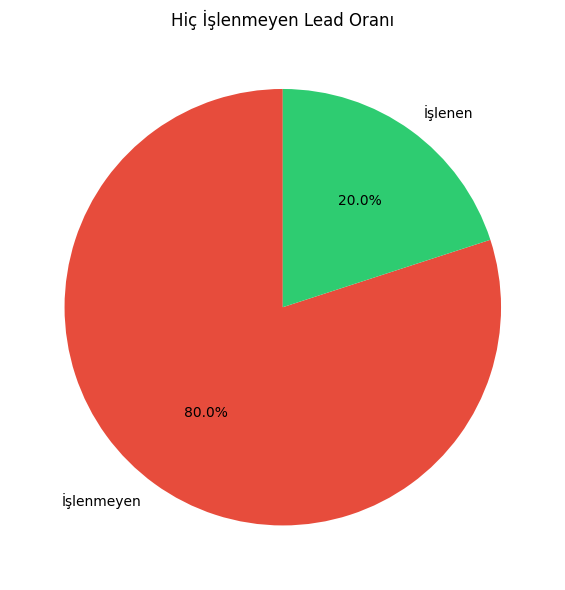

In [11]:
with open("sql/Lead_Analizi/hic_islenmeyen_lead_orani___.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_islenmyen = pd.read_sql(query, engine)

oran = float(df_islenmyen["hic_islenmeyen_lead_orani"].iloc[0])
islenen = 100 - oran

plt.figure(figsize=(6, 6))
plt.pie([oran, islenen], labels=["İşlenmeyen", "İşlenen"],
        autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"], startangle=90)
plt.title("Hiç İşlenmeyen Lead Oranı")
plt.tight_layout()
plt.show()

**Yorum — Operasyonel Problem Tespiti:** Hiç işlenmeyen lead oranı dikkat çekici düzeydedir. Bu lead'lere hiç randevu atanmamış ve potansiyel gelir kaybına neden olmuştur.

**İş etkisi:** Her işlenmeyen lead, potansiyel bir portföy ve dolayısıyla potansiyel bir komisyon geliri kaybıdır. Lead başına maliyet verisi (pazarlama analizi) ile çapraz değerlendirildiğinde, karşılığı alınamayan pazarlama harcaması anlamına gelmektedir.

**Öneri:** Lead takip süreçlerinin iyileştirilmesi, otomatik hatırlatma/eskalasyon sistemlerinin kurulması, lead dağıtım algoritmasının gözden geçirilmesi ve belirli süre içinde işlenmeyen lead'lerin yeniden dağıtılması önerilmektedir. Bu bulgu, yönetimin "lead'ler doğru yönetilmiyor olabilir" şüphesini doğrudan desteklemektedir.

# Portföy Analizi
1. ### Portföy Satış Oranı

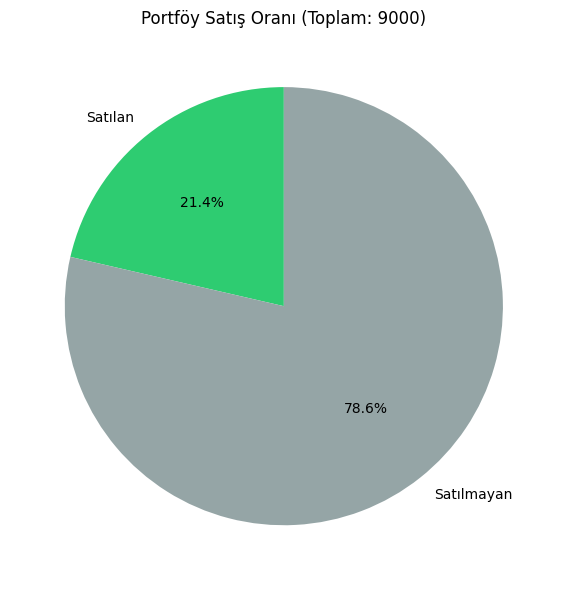

In [12]:
with open("sql/Portfoy_Analizi/Portfoy_Satis_Orani.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_pf_satis = pd.read_sql(query, engine)

satilan = int(df_pf_satis["satilan_portfoy"].iloc[0])
toplam = int(df_pf_satis["toplam_portfoy"].iloc[0])
satilmayan = toplam - satilan

plt.figure(figsize=(6, 6))
plt.pie([satilan, satilmayan], labels=["Satılan", "Satılmayan"],
        autopct="%1.1f%%", colors=["#2ecc71", "#95a5a6"], startangle=90)
plt.title(f"Portföy Satış Oranı (Toplam: {toplam})")
plt.tight_layout()
plt.show()

**Yorum:** Toplam portföy içinde satılan portföy oranı düşüktür.Bu, portföy yönetiminde optimizasyon fırsatlarına işaret etmektedir. Satılmayan portföylerin neden satılamadığı (fiyatlandırma, konum, mülk durumu, pazarlama eksikliği vb.) detaylı analiz edilmelidir.

2. ### Ortalama Satış Süresi

In [13]:
with open("sql/Portfoy_Analizi/Ort_Satis_Suresi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ort_sure = pd.read_sql(query, engine)

sure = df_ort_sure["ortalama_satis_suresi_gun"].iloc[0]
print(f"Ortalama Satış Süresi: {sure:.1f} gün")

Ortalama Satış Süresi: 40.0 gün


**Yorum:** Ortalama satış süresi **40 gün** olarak hesaplanmıştır. Bu, portföye alınan bir mülkün ortalama yaklaşık 5-6 haftada satıldığı anlamına gelmektedir. Pazar koşullarına göre bu süre değerlendirilebilir; sürenin kısaltılması için fiyatlandırma, medya kalitesi ve pazarlama kanallarının etkinliği gözden geçirilmelidir.

3. ### Ortalama ve Toplam Satış Hacmi

In [14]:
with open("sql/Portfoy_Analizi/Ort_ve_Toplam_satis_Hacmi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_hacim = pd.read_sql(query, engine)

ort_fiyat = df_hacim["ortalama_satis_fiyati_try"].iloc[0]
toplam_hacim = df_hacim["toplam_satis_hacmi_try"].iloc[0]

print(f"Ortalama Satış Fiyatı: {ort_fiyat:,.2f} TL")
print(f"Toplam Satış Hacmi: {toplam_hacim:,.2f} TL")

Ortalama Satış Fiyatı: 279,948,833.33 TL
Toplam Satış Hacmi: 25,195,395,000.00 TL


**Yorum:** Tamamlanan işlemler bazında:
- **Ortalama satış fiyatı:** ~280 milyon TL
- **Toplam satış hacmi:** ~25.2 milyar TL

Yüksek ortalama satış fiyatı, portföylerin genellikle orta-üst segmentte konumlandığını göstermektedir.

4. ### Liste Fiyatı vs Satış Fiyatı Farkı (%)

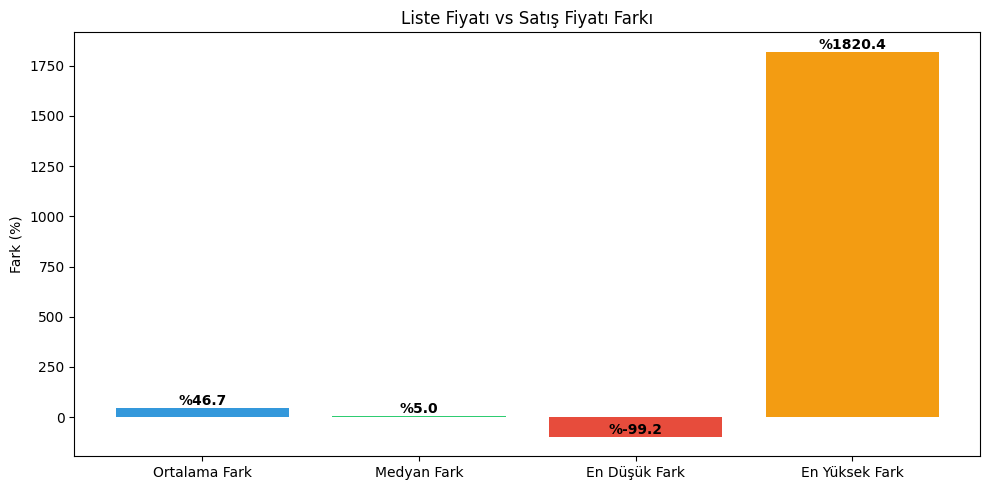

In [15]:
with open("sql/Portfoy_Analizi/Liste_fiyatı_vs_Satis_Fiyatı_Farki.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_fark = pd.read_sql(query, engine)

labels = ["Ortalama Fark", "Medyan Fark", "En Düşük Fark", "En Yüksek Fark"]
values = [float(df_fark["ortalama_fark"].iloc[0]), float(df_fark["medyan_fark"].iloc[0]),
          float(df_fark["en_dusuk_fark"].iloc[0]), float(df_fark["en_yuksek_fark"].iloc[0])]

plt.figure(figsize=(10, 5))
colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12"]
bars = plt.bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"%{val:.1f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("Fark (%)")
plt.title("Liste Fiyatı vs Satış Fiyatı Farkı")
plt.tight_layout()
plt.show()

**Yorum:** Liste fiyatı ile gerçekleşen satış fiyatı arasındaki fark (%) incelendiğinde, ortalama ve medyan fark değerleri pazarlık payı hakkında bilgi vermektedir. En düşük ve en yüksek fark değerleri arasındaki geniş aralık, farklı mülk tiplerinde ve pazar koşullarında fiyat esnekliğinin değiştiğini göstermektedir. Negatif fark değerleri liste fiyatının altında satış yapıldığına, pozitif değerler ise liste fiyatının üzerinde satış yapıldığına işaret eder.
Buradaki ortalama ve medyan Danışmanın pazarlık gücünü temsil eder.

**Veri Farkındalığı :** Veri setinde kasıtlı olarak bırakılan aykırı değerler ve operasyonel istisnalara bir örnektir. bazı portföyler bilerek değerinin çok altında ve çok üstünde satılmıştır veya liste fiyatı belirlenmiştir.

5. ### En Hızlı Satılan Portföy Tipleri

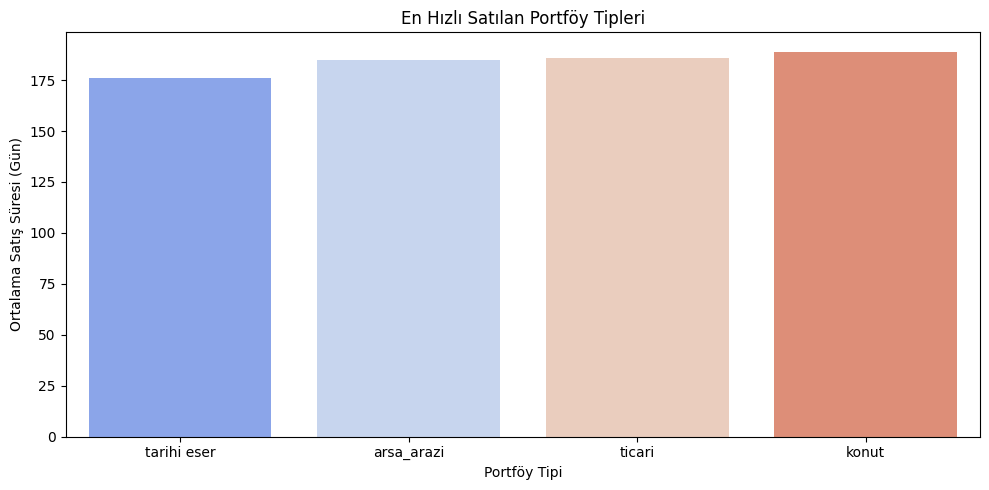

In [17]:
with open("sql/Portfoy_Analizi/En_Hızlı_satilan_Portfoy_tipleri.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_pf_hiz = pd.read_sql(query, engine)
df_pf_hiz["ort_sure_gun"] = df_pf_hiz["ortalama_satis_suresi_interval"].dt.days

plt.figure(figsize=(10, 5))
sns.barplot(data=df_pf_hiz, x="portfoy_tipi", y="ort_sure_gun", hue="portfoy_tipi", palette="coolwarm", legend=False)
plt.xlabel("Portföy Tipi")
plt.ylabel("Ortalama Satış Süresi (Gün)")
plt.title("En Hızlı Satılan Portföy Tipleri")
plt.tight_layout()
plt.show()

**Yorum:** Portföy tiplerinin ortalama satış süreleri karşılaştırıldığında, mülk tiplerinin satış süreleri arasında fark görülmemektedir. Gerçekte hızlı satılan mülk tipleri yüksek talep göstergesidir ve bu tiplere yönelik portföy artırımı stratejik olarak değerlendirilebilir.

6. ### Portföy Tipi Satış Performansı (Tamamlanan İşlemler)(2.Porblem)

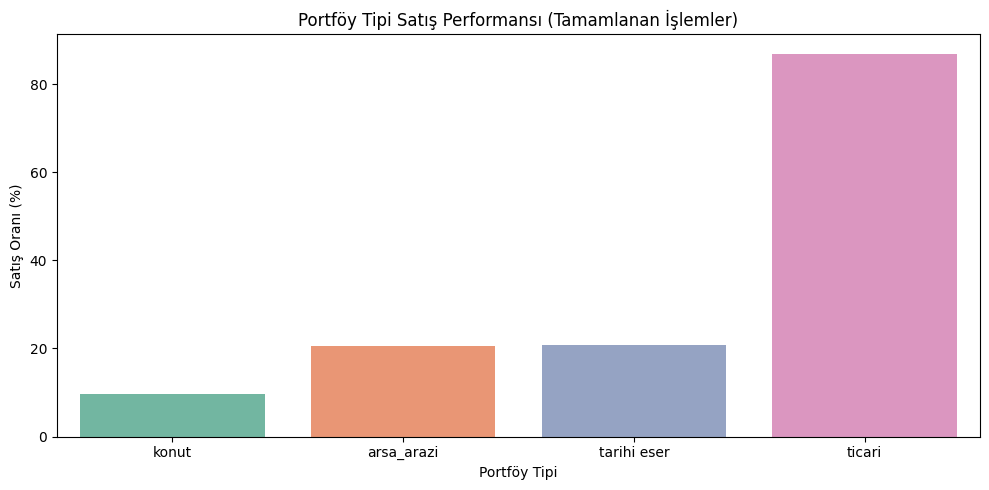

In [18]:
with open("sql/Portfoy_Analizi/portfoy_tipi_satis_orani___.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_pf_perf = pd.read_sql(query, engine)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_pf_perf, x="portfoy_tipi", y="satis_orani_yuzde", hue="portfoy_tipi", palette="Set2", legend=False)
plt.xlabel("Portföy Tipi")
plt.ylabel("Satış Oranı (%)")
plt.title("Portföy Tipi Satış Performansı (Tamamlanan İşlemler)")
plt.tight_layout()
plt.show()

**Yorum — Operasyonel Problem Tespiti:** Tamamlanan işlemler bazında portföy tipi satış performansı, Konut Tipinin yaklaşık %9 olması , arsa-arazi,tarihi_eser tiplerinin de yaklaşık %20 olması, Portföy -> İşlem oranındaki %21'lik oranı açıklamaktadır. Ticari Portföy tipinin yüksek çıkması , sayısının azlığı nedeniyle genel Portföy -> İşlem hacmini ancak %21'e çıkartabilmiştir. Portföylerdeki Konut, Arsa-Arazi,Tarihi Eser varlıkların kalitesiz olduğunu göstermektedir.

# Pazarlama Analizi
1. ### Pazarlama Brüt ROI (Kanal Bazında)

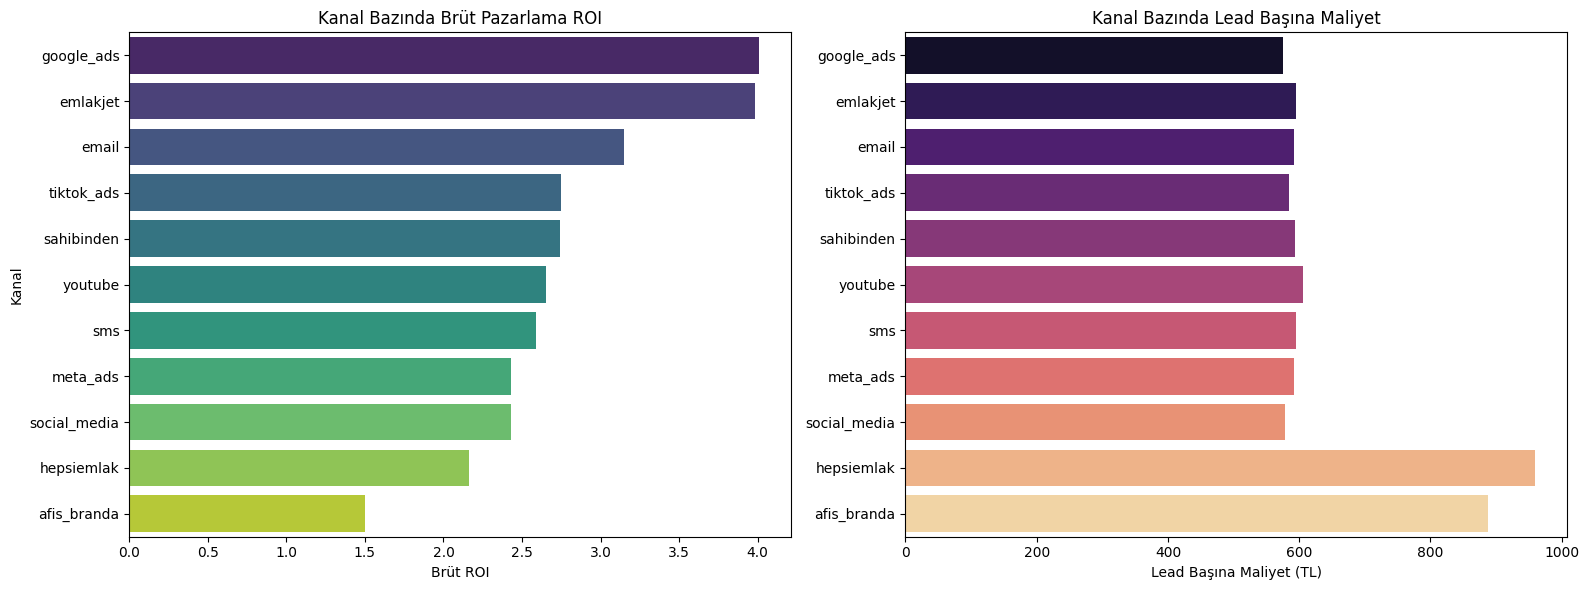

In [19]:
with open("sql/Pazarlama_Analizi/Pazarlama_Analizi_Brut_ROI.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_paz_brut = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_paz_brut, x="pazarlama_roi", y="kanal", hue="kanal", palette="viridis", legend=False, ax=axes[0])
axes[0].set_xlabel("Brüt ROI")
axes[0].set_ylabel("Kanal")
axes[0].set_title("Kanal Bazında Brüt Pazarlama ROI")

sns.barplot(data=df_paz_brut, x="lead_basina_maliyet_try", y="kanal", hue="kanal", palette="magma", legend=False, ax=axes[1])
axes[1].set_xlabel("Lead Başına Maliyet (TL)")
axes[1].set_ylabel("")
axes[1].set_title("Kanal Bazında Lead Başına Maliyet")

plt.tight_layout()
plt.show()

**Yorum :** Kanal bazında pazarlama brüt ROI'leri arasında belirgin farklar bulunmaktadır. Bu durum, yönetimin "pazarlama bütçesi verimsiz kullanılıyor olabilir" şüphesiyle doğrudan ilişkilidir.

Düşük ROI'li kanallara yapılan harcamalar, bütçe israfı anlamına gelmektedir. Lead başına maliyet ile ROI birlikte incelendiğinde, düşük lead maliyetinin her zaman yüksek ROI anlamına gelmediği görülmektedir — lead kalitesi ve dönüşüm oranı da kritik faktörlerdir. Bütçe, yüksek ROI'li kanallara yeniden dağıtılmalıdır.

**Veri kalitesi notu:** Hesaplamalarda Case Study'de belirtilen kur sabitleri (EUR=30, USD=25) ve komisyon formülü (brut_islem_tutari × komisyon_orani) kullanılmıştır.

2. ### Pazarlama Net Ciro ROI (Kanal Bazında)(3.Problem)

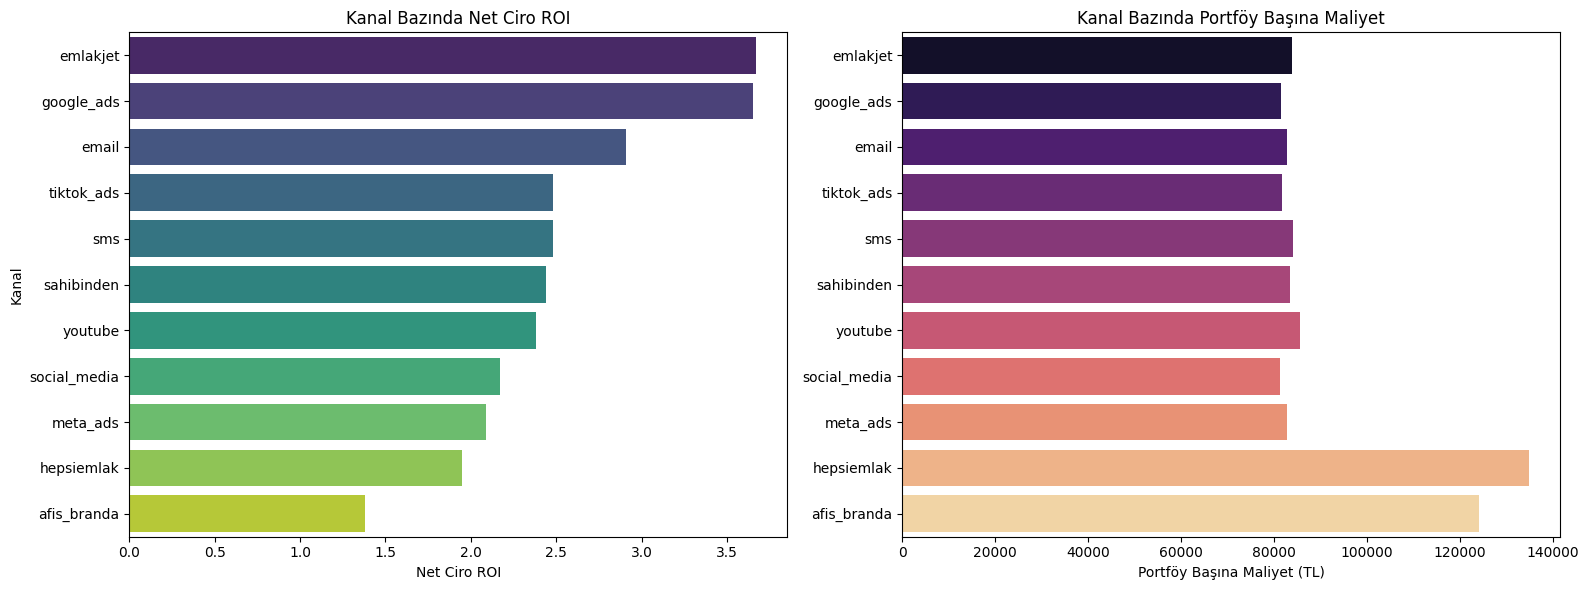

In [20]:
with open("sql/Pazarlama_Analizi/Pazarlama_Analizi_NetCiro_ROI___.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_paz_net = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_paz_net, x="pazarlama_roi_net_ciro", y="kanal", hue="kanal", palette="viridis", legend=False, ax=axes[0])
axes[0].set_xlabel("Net Ciro ROI")
axes[0].set_ylabel("Kanal")
axes[0].set_title("Kanal Bazında Net Ciro ROI")

sns.barplot(data=df_paz_net, x="portfoy_basina_maliyet_try", y="kanal", hue="kanal", palette="magma", legend=False, ax=axes[1])
axes[1].set_xlabel("Portföy Başına Maliyet (TL)")
axes[1].set_ylabel("")
axes[1].set_title("Kanal Bazında Portföy Başına Maliyet")

plt.tight_layout()
plt.show()

**Yorum — Operasyonel Problem Tespiti :** Net ciro üzerinden hesaplanan ROI, brüt ROI'ye kıyasla referral (%20 kesinti) ve cooperation (%50 kesinti) paylarını dikkate aldığından daha gerçekçi bir tablo sunmaktadır. Bazı kanallar brüt ROI'de yüksek görünse de, net ciro ROI'sinde sıralama değişebilmektedir. Bütçe kararları net ciro ROI üzerinden verilmelidir. 

Afiş Branda gibi pazarlama yöntemlerinin bariz bir ROI kaybına yol açtığı gözlemlenmektedir.

3. ### Kanal Bazında Ortalama Günlük Lead

In [92]:
with open("sql/Pazarlama_Analizi/kanal_bazında_ort_gunluk_lead_analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_gunluk_lead = pd.read_sql(query, engine)
df_gunluk_lead


,kanal,toplam_lead,toplam_kampanya_suresi_gun,ortalama_gunluk_lead
0,google_ads,64215,9561,6.72
1,social_media,64002,9535,6.71
2,sms,64143,9579,6.70
3,sahibinden,63819,9545,6.69
4,meta_ads,63735,9530,6.69
5,hepsiemlak,63936,9555,6.69
6,youtube,64071,9597,6.68
7,emlakjet,63903,9565,6.68
8,email,63729,9570,6.66
9,tiktok_ads,63735,9585,6.65


**Yorum:** Kanal bazında ortalama günlük lead sayıları, her kanalın lead üretim verimliliğini ortaya koymaktadır. Bu metrik kampanya süreleriyle normalize edildiğinden, kanallar arası adil bir karşılaştırma sağlamaktadır.Günlük lead üretimi kanallar için benzer seviyede olsa da pazarlama harcaması bakımından ciddi farklılıklar görülmüştür.

# Medya Analizi
1. ### Medya Sayısı ve Satış Oranı İlişkisi

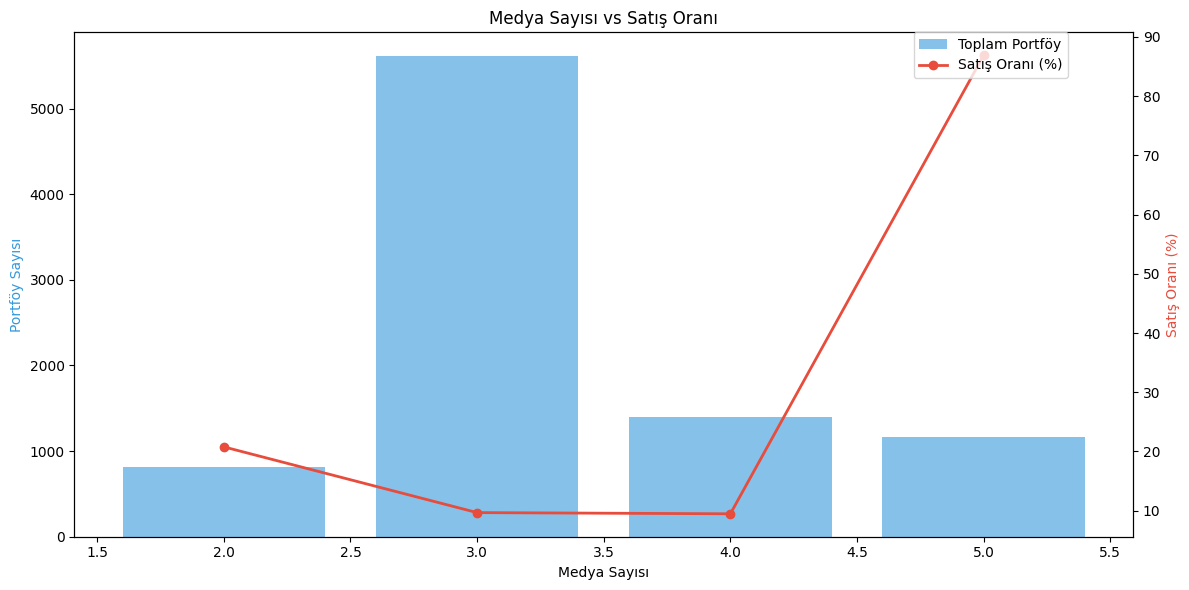

In [22]:
with open("sql/Medya_Analizi/Medya_sayisi_analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_medya_sayi = pd.read_sql(query, engine)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_medya_sayi["medya_sayisi"], df_medya_sayi["toplam_portfoy"], color="#3498db", alpha=0.6, label="Toplam Portföy")
ax1.set_xlabel("Medya Sayısı")
ax1.set_ylabel("Portföy Sayısı", color="#3498db")

ax2 = ax1.twinx()
ax2.plot(df_medya_sayi["medya_sayisi"], df_medya_sayi["satis_orani_yuzde"], color="#e74c3c", marker="o", linewidth=2, label="Satış Oranı (%)")
ax2.set_ylabel("Satış Oranı (%)", color="#e74c3c")

fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.95))
plt.title("Medya Sayısı vs Satış Oranı")
plt.tight_layout()
plt.show()

**Yorum:** Medya sayısı ile satış oranı arasında pozitif bir ilişki gözlemlenmektedir: Daha fazla medya içeriğine (fotoğraf, video, drone vb.) sahip portföylerin satış oranı genel olarak daha yüksektir. Ancak belirli bir noktadan sonra ek medya eklemenin marjinal faydası azalabilir. Portföy başına optimum medya sayısı belirlemek maliyet-etkinlik açısından önemlidir.

2. ### Medya Tipi Analizi

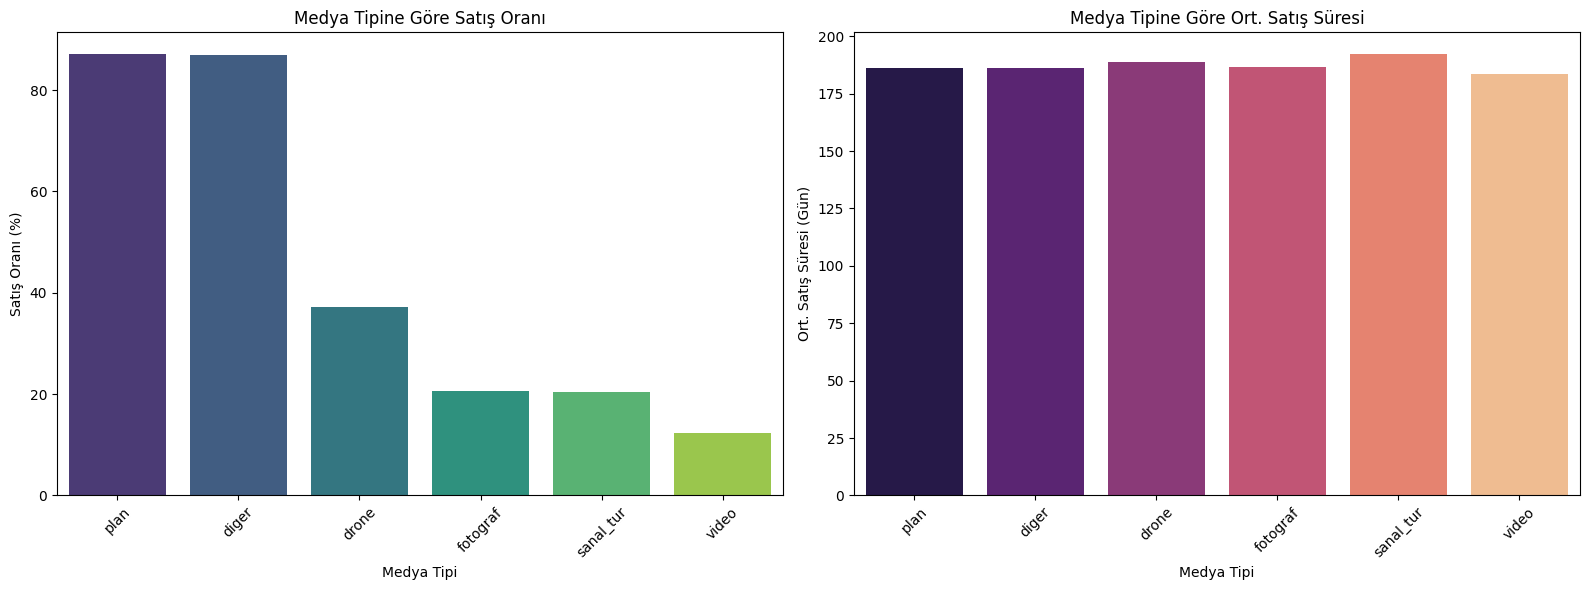

In [23]:
with open("sql/Medya_Analizi/medya_tipi_analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_medya_tip = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_medya_tip, x="medya_tipi", y="satis_orani_yuzde", hue="medya_tipi", palette="viridis", legend=False, ax=axes[0])
axes[0].set_xlabel("Medya Tipi")
axes[0].set_ylabel("Satış Oranı (%)")
axes[0].set_title("Medya Tipine Göre Satış Oranı")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=df_medya_tip, x="medya_tipi", y="ortalama_satis_suresi_gun", hue="medya_tipi", palette="magma", legend=False, ax=axes[1])
axes[1].set_xlabel("Medya Tipi")
axes[1].set_ylabel("Ort. Satış Süresi (Gün)")
axes[1].set_title("Medya Tipine Göre Ort. Satış Süresi")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Yorum:** Farklı medya tipleri (fotoğraf, video, drone, sanal tur, plan vb.) satış oranı üzerinde farklı etkilere sahip olduğu görülse de , Medya tipleri portföy bazında birbirini dışlamadığı için bu analiz **nedensel yorum üretmez**. Çünkü bir portföyde genelde **birden fazla** medya tipi bulunur. Daha doğru bir yaklaşım portföy seviyesinde feature engineering yaparak satış üzerinde etkisini modellemektir. 

3. ### Profesyonel Çekim & Medya Sayısı Analizi

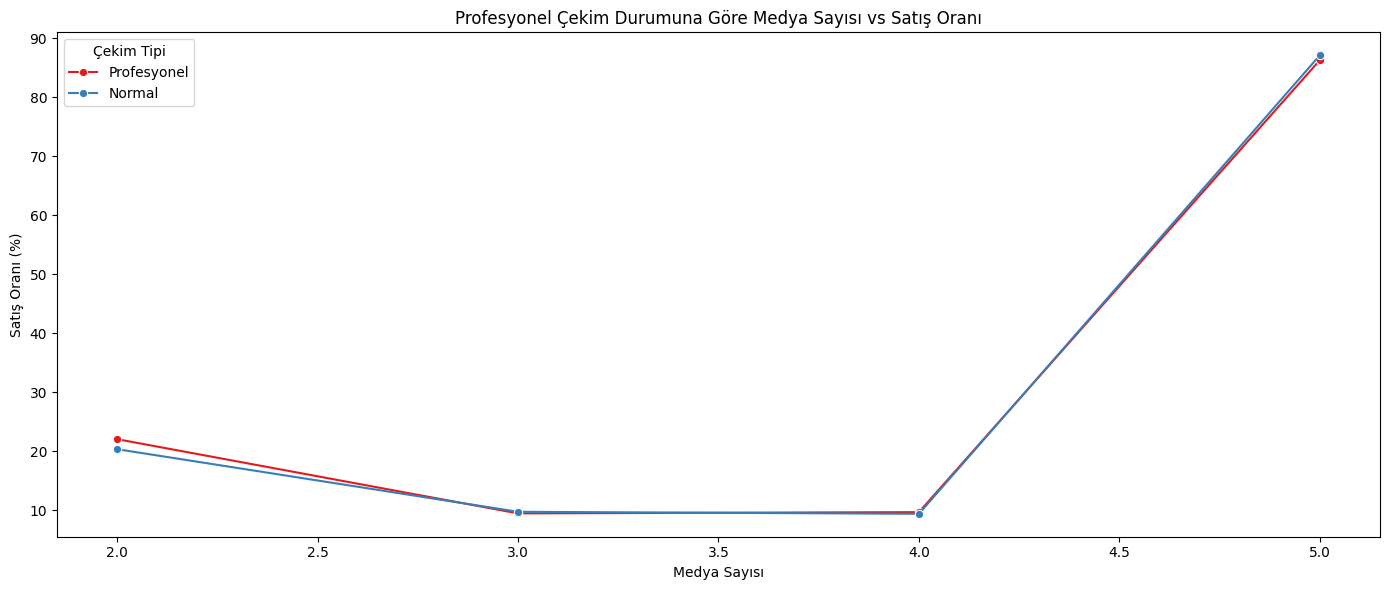

In [24]:
with open("sql/Medya_Analizi/prof_cekim_medya_sayisi_analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_prof_sayi = pd.read_sql(query, engine)
df_prof_sayi["profesyonel_cekim"] = df_prof_sayi["profesyonel_cekim"].map({True: "Profesyonel", False: "Normal", None: "Bilinmiyor"})

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_prof_sayi, x="medya_sayisi", y="satis_orani_yuzde",
             hue="profesyonel_cekim", marker="o", palette="Set1")
plt.xlabel("Medya Sayısı")
plt.ylabel("Satış Oranı (%)")
plt.title("Profesyonel Çekim Durumuna Göre Medya Sayısı vs Satış Oranı")
plt.legend(title="Çekim Tipi")
plt.tight_layout()
plt.show()

**Yorum:** Profesyonel çekim yapılmış medya içeriklerine sahip portföylerin, normal çekime kıyasla satış oranı farkı medya sayısı ile birlikte incelenmiştir. Medya sayısı arttıkça profesyonel çekim avantajı gözlemlenememiştir. Bu, verinin kalitesi açısından dummy veri olduğu için gerçekleşiyor olabilir.

4. ### Profesyonel Çekim & Medya Tipi Analizi

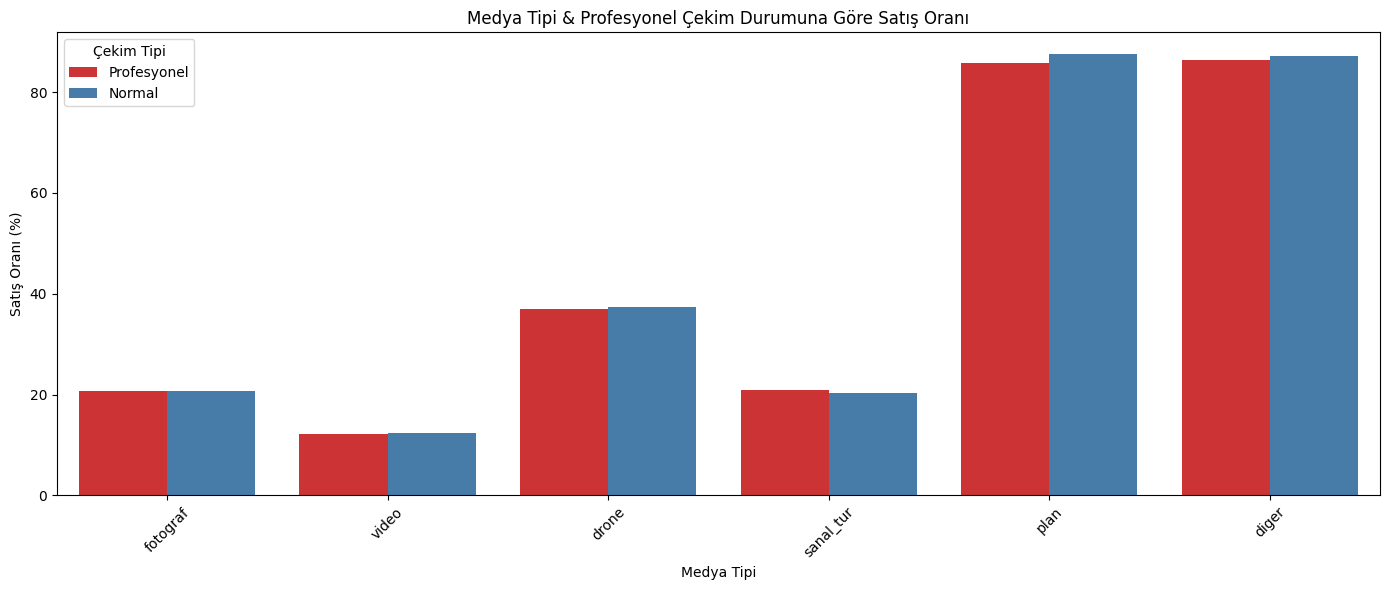

In [25]:
with open("sql/Medya_Analizi/prof_cekim_medya_tipi_analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_prof_tip = pd.read_sql(query, engine)
df_prof_tip["profesyonel_cekim"] = df_prof_tip["profesyonel_cekim"].map({True: "Profesyonel", False: "Normal", None: "Bilinmiyor"})

plt.figure(figsize=(14, 6))
sns.barplot(data=df_prof_tip, x="medya_tipi", y="satis_orani_yuzde",
            hue="profesyonel_cekim", palette="Set1")
plt.xlabel("Medya Tipi")
plt.ylabel("Satış Oranı (%)")
plt.title("Medya Tipi & Profesyonel Çekim Durumuna Göre Satış Oranı")
plt.legend(title="Çekim Tipi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Yorum:** Profesyonel çekim etkisi medya tipine göre farklılık göstermemektedir. Bu net bir şekilde anomalidir.

**Veri Kalitesi Notu :** Veri setinde kasıtlı olarak bırakılan aykırı durumlar ve operasyonel istisnalar profesyonel çekim etkisini **etkisizleştirmiştir**.

5. ### Medya Tipine Göre Profesyonel Çekim Oranı(4.Problem)

In [93]:
with open("sql/Medya_Analizi/medya_tipine_gore_prof_cekim_orani___.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_prof_oran = pd.read_sql(query, engine)

df_prof_oran

,medya_tipi,profesyonel_cekim_orani_yuzde
0,sanal_tur,25.05
1,video,25.01
2,fotograf,25.00
3,drone,25.00
4,diger,24.98
5,plan,24.92


**Yorum — Operasyonel Problem Tespiti :** Medya tipleri arasında profesyonel çekim kullanım oranı farklılık göstermemektedir. Özellikle satış oranı üzerinde yüksek etkisi olan medya tiplerinde bu oranın düşük olması, kaçırılmış bir fırsat olarak değerlendirilebilir.

# İşlem Analizi
1. ### İptal Nedeni ve Sayısı (5. Problem)


In [27]:
with open("sql/Islem_Analizi/Islem_Durumu_Sayisi.sql", "r", encoding="utf-8") as f:
    query2 = f.read()
df_islem_sayisi = pd.read_sql(query2, engine)
df_islem_sayisi.head()

,islem_durumu,islem_durumu_sayisi
0,tamamlandi,1862
1,iptal,63


In [28]:
with open("sql/Islem_Analizi/Iptal_Nedeni_ve_Sayisi.sql", "r", encoding="utf-8") as f:
    query1 = f.read()
df_iptal = pd.read_sql(query1, engine)
df_iptal.head()


,iptal_nedeni,iptal_sayisi
0,Finansman cikmadi,63


**Yorum:** Tüm iptal işlemlerinin nedeni finansman çıkmaması olduğu için satış pipeline’ında müşteri finansal uygunluğu erken aşamada kontrol edilmiyor olabilir.

# Operasyonel Analiz

**Yönetim şüphesinde yanılmıştır.Randevular verimli gerçekleşiyor. Funnel Analizinde      
*Randevu → Portföy: %93.97*  dönüşüm oranı olduğu net bir şekilde görülmüştür.**

**Yönetim şüphelerinde haklıdır. Lead doğru yönetilmiyor.**
1. Problem: Lead’lerin etkin yönetilememesi
   - Problemin tanımı: Lead’lerin satışa dönüşüm oranı düşük.
   - Kullanılan veri/metric: Lead Analizi.2 ve Çalışan Analizi.4'e göz atın.
   - Olası nedeni: Lead atamalarında gecikme, çalışan başına düşen lead sayısının yüksek olması veya takip eksikliği. Çalışanların başarısız olması.
   - İş üzerindeki etkisi: Satış fırsatlarının kaçırılması, gelir kaybı ve pazarlama verimliliğinin düşmesi.
   - Çözüm önerisi: Lead yönetimi için otomatik hatırlatıcı ve SLA bazlı takip; çalışan başına optimum lead dağılımı ve performans takibi.

**Yönetim şüphelerinde haklıdır.Portföy kalitesinin düşük.**

2. Problem: Portföy kalitesinin düşük olması
   - Problemin tanımı: Bazı portföylerin satış oranları çok düşük ve ortalama satış süresi uzun.
   - Kullanılan veri/metric: Portföy Analizi.7'ye göz atın.
   - Olası nedeni: Medya eksikliği, profesyonel çekim yokluğu, yüksek liste fiyatları.
   - İş üzerindeki etkisi: Stokta bekleyen portföyler, nakit akışının yavaşlaması ve çalışan motivasyonunun düşmesi.
   - Çözüm önerisi: Medya içeriklerinin artırılması (fotoğraf/video/sanal tur); profesyonel çekimlerin önceliklendirilmesi; portföy fiyatlandırma optimizasyonu.

**Yönetim şüphelerinde haklıdır.Pazarlama bütçesi verimsiz kullanılıyor.**

3. Problem: Pazarlama bütçesi verimsiz kullanımı
   - Problemin tanımı: Bazı pazarlama kanalları yüksek harcama ile düşük lead/portföy üretimi sağlıyor.
   - Kullanılan veri/metric: Pazarlama Analizi.2'ye göz atın. 
   - Olası nedeni: Hedefleme hataları veya düşük performanslı kampanyalar.
   - İş üzerindeki etkisi: Pazarlama bütçesinin etkin kullanılamaması, maliyet artışı ve yatırım geri dönüşünün düşmesi.
   - Çözüm önerisi: Kanal bazlı ROI analizi ile düşük performanslı kanalların optimize edilmesi; A/B testleri; harcama planlamasının veri odaklı yapılması.

**Yönetim bu durumu değerlendirmemiştir.**

4. Problem: Medya içeriklerinin satış performansına etkisinin düşük olması
   - Problemin tanımı: Portföylerde medya çeşitliliği veya profesyonel çekim eksikliği satış performansını olumsuz etkiliyor.
   - Kullanılan veri/metric: Medya Analizi.5'e göz atın.
   - Olası nedeni: Bazı portföyler sadece bir medya tipine sahip; profesyonel çekim yok.
   - İş üzerindeki etkisi: Satış süresi uzuyor, portföy stokta kalıyor ve satış gelirleri düşüyor.
   - Çözüm önerisi: Her portföy için minimum medya standartları (fotoğraf + video + sanal tur) belirlemek; profesyonel çekim zorunluluğu; medya optimizasyonu ile portföy satış süresini kısaltmak.

**Yönetim bu durumu değerlendirmemiştir.**

5. Problem: İşlem iptal durumunun yönetilmemesi.
   - Problemin tanımı: İptallerin tamamı aynı nedenden gerçekleşiyor.
   - Kullanılan veri/metric: İşlem Analizi.1'e göz atın.
   - Olası nedeni: Alıcı finansmanının son aşamada başarısız olması,
   - İş üzerindeki etkisi: Çalışanların zaman kaybı, operasyonel maliyetlerin artmasına, satış pipeline’ının uzamasına sebep olabilir.
   - Çözüm önerisi: Satış öncesinde müşteri finansman uygunluğu kontrolü yapılmalı.

# Diğer Analiz Beklentileri

1. ### Ofis Bazlı Funnel Analizi

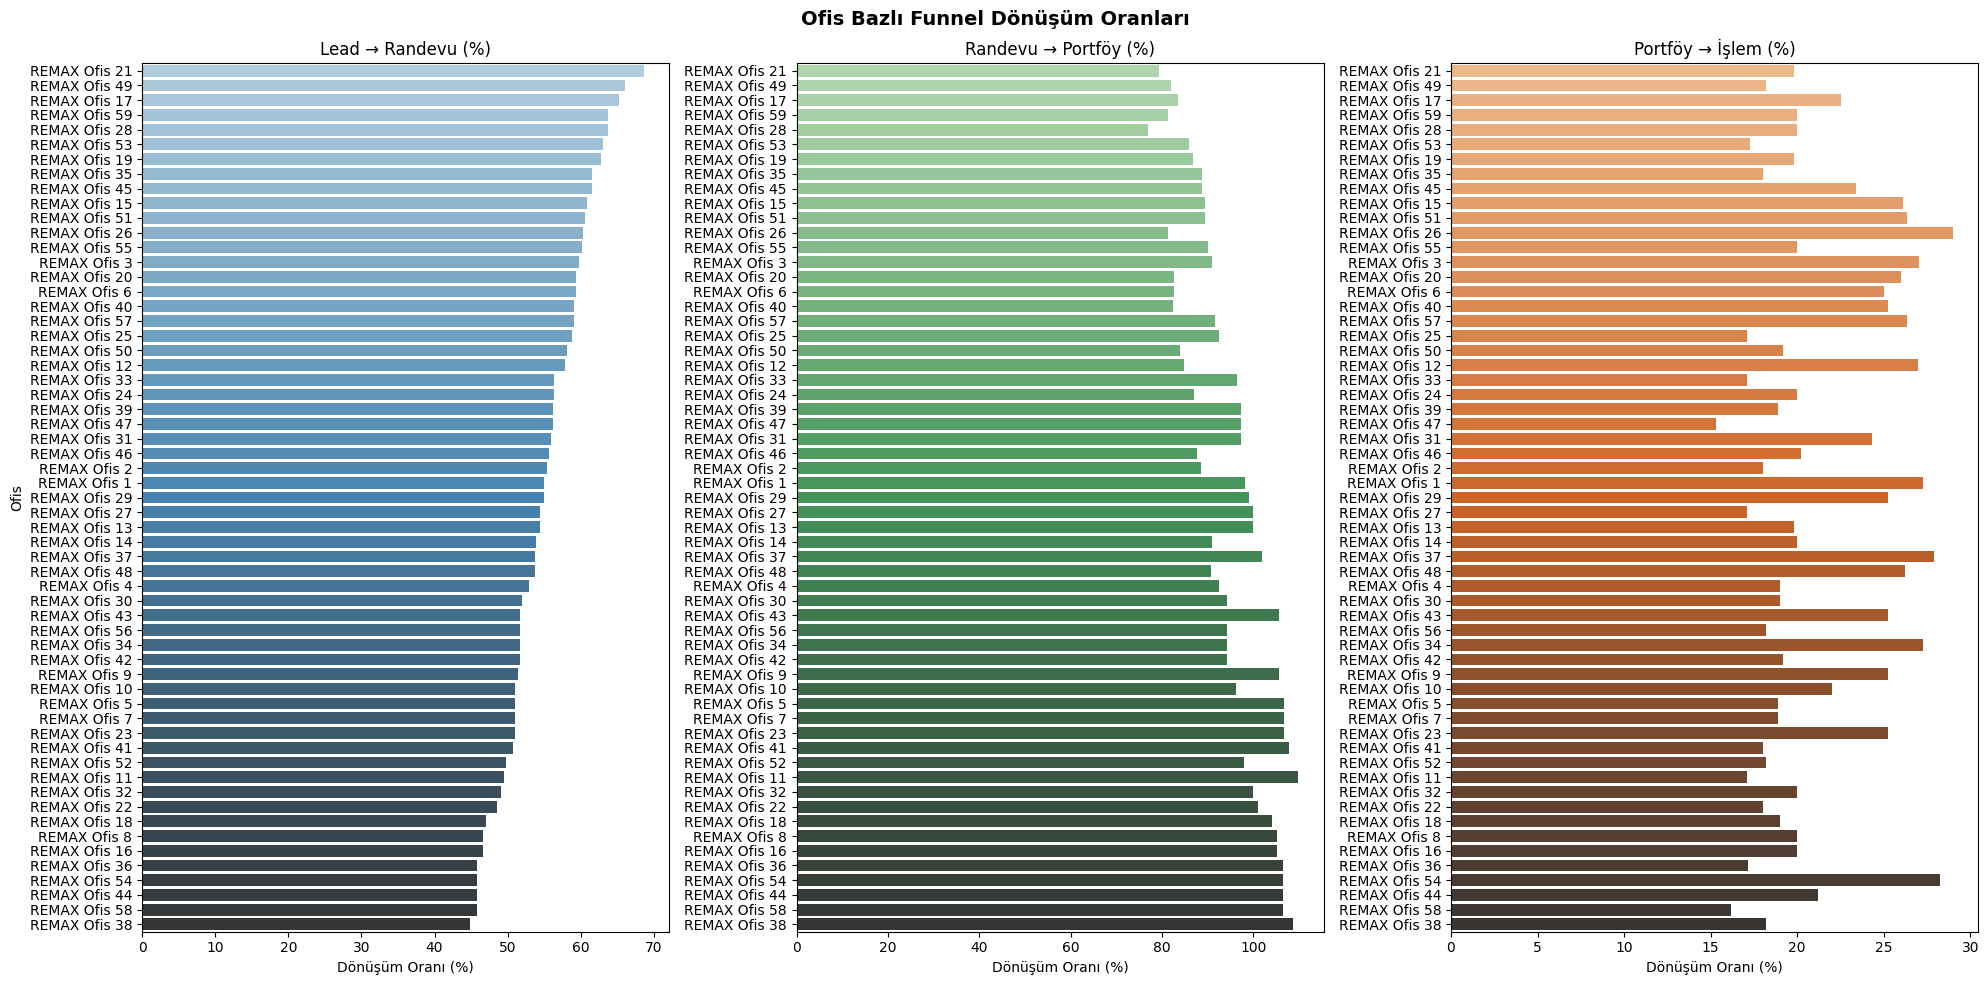

In [94]:
with open("sql/Diger_Analizler/1_ofis_bazli_funnel.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ofis_funnel = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

sns.barplot(data=df_ofis_funnel, x="lead_to_randevu_pct", y="ofis_adi", hue="ofis_adi", palette="Blues_d", legend=False, ax=axes[0], errorbar=None)
axes[0].set_title("Lead → Randevu (%)")
axes[0].set_xlabel("Dönüşüm Oranı (%)")
axes[0].set_ylabel("Ofis")

sns.barplot(data=df_ofis_funnel, x="randevu_to_portfoy_pct", y="ofis_adi", hue="ofis_adi", palette="Greens_d", legend=False, ax=axes[1], errorbar=None)
axes[1].set_title("Randevu → Portföy (%)")
axes[1].set_xlabel("Dönüşüm Oranı (%)")
axes[1].set_ylabel("")

sns.barplot(data=df_ofis_funnel, x="portfoy_to_islem_pct", y="ofis_adi", hue="ofis_adi", palette="Oranges_d", legend=False, ax=axes[2], errorbar=None)
axes[2].set_title("Portföy → İşlem (%)")
axes[2].set_xlabel("Dönüşüm Oranı (%)")
axes[2].set_ylabel("")

plt.suptitle("Ofis Bazlı Funnel Dönüşüm Oranları", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Yorum:** Ofis bazlı funnel analizi, her ofisin lead yönetimi ve satış sürecindeki etkinliğini karşılaştırmaya olanak tanır. Lead→Randevu dönüşümü düşük olan ofislerde lead takip süreçleri gözden geçirilmeli; Portföy→İşlem dönüşümü düşük ofislerde ise portföy kalitesi, fiyatlandırma stratejisi ve danışman yetkinlikleri sorgulanmalıdır. Ofisler arası farklılıklar, bölgesel pazar dinamiklerinden kaynaklanabileceği gibi, operasyonel verimlilik farklarını da yansıtmaktadır.

2. ### Ofis Bazlı Ortalama İşlem Süresi Analizi

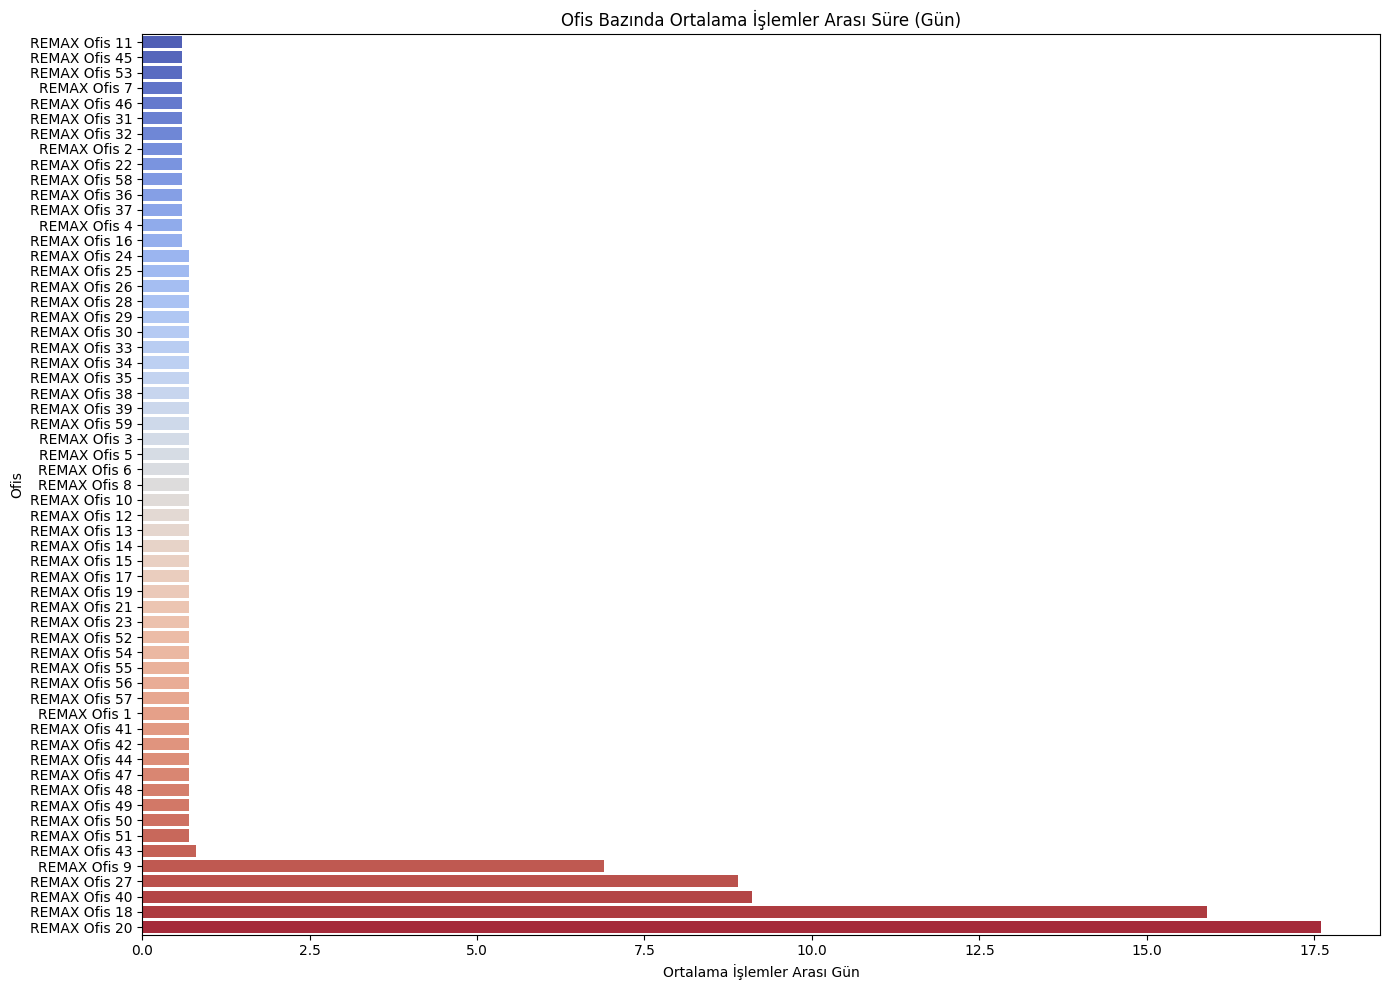

In [95]:
with open("sql/Diger_Analizler/2_ofis_bazli_ort_islem_tarihi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ofis_tarih = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(14, 10))
sns.barplot(data=df_ofis_tarih, x="ort_islemler_arasi_gun", y="ofis_adi", hue="ofis_adi", palette="coolwarm", legend=False, errorbar=None, ax=ax)
ax.set_xlabel("Ortalama İşlemler Arası Gün")
ax.set_ylabel("Ofis")
ax.set_title("Ofis Bazında Ortalama İşlemler Arası Süre (Gün)")
plt.tight_layout()
plt.show()

**Yorum:** Ofislerin işlem sıklığı, operasyonel tempo hakkında önemli bir göstergedir. İşlemler arası sürenin kısa olduğu ofisler daha yüksek bir işlem ritmine sahiptir; bu durum aktif danışman sayısı, bölgedeki talep yoğunluğu ve portföy çeşitliliği ile ilişkilendirilebilir. İlk ve son işlem tarihleri arasındaki fark, ofisin aktif olduğu süreyi de göstermektedir.

3. ### Kanal Bazlı Funnel Analizi

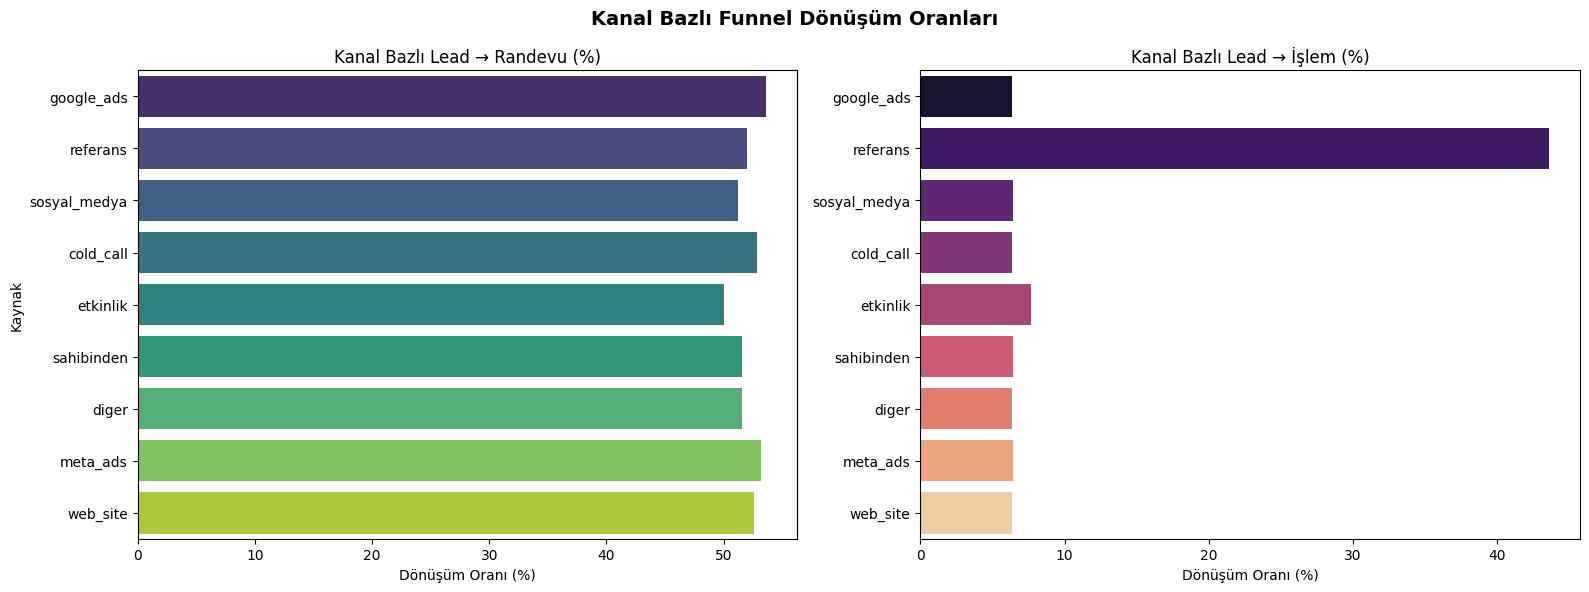

,kaynak,lead_sayisi,randevu_sayisi,portfoy_sayisi,islem_sayisi,lead_to_randevu_pct,lead_to_islem_pct
0,google_ads,1334,715,690,85,53.60,6.37
1,referans,1334,693,689,581,51.95,43.55
2,sosyal_medya,1334,683,689,86,51.20,6.45
3,cold_call,1333,704,688,85,52.81,6.38
4,etkinlik,1333,667,689,102,50.04,7.65
5,sahibinden,1333,687,689,86,51.54,6.45
6,diger,1333,687,688,85,51.54,6.38
7,meta_ads,1333,709,688,86,53.19,6.45
8,web_site,1333,701,690,85,52.59,6.38


In [44]:
with open("sql/Diger_Analizler/4_kanal_bazli_funnel.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_kanal_funnel = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_kanal_funnel, x="lead_to_randevu_pct", y="kaynak", hue="kaynak", palette="viridis", legend=False, ax=axes[0], errorbar=None)
axes[0].set_title("Kanal Bazlı Lead → Randevu (%)")
axes[0].set_xlabel("Dönüşüm Oranı (%)")
axes[0].set_ylabel("Kaynak")

sns.barplot(data=df_kanal_funnel, x="lead_to_islem_pct", y="kaynak", hue="kaynak", palette="magma", legend=False, ax=axes[1], errorbar=None)
axes[1].set_title("Kanal Bazlı Lead → İşlem (%)")
axes[1].set_xlabel("Dönüşüm Oranı (%)")
axes[1].set_ylabel("")

plt.suptitle("Kanal Bazlı Funnel Dönüşüm Oranları", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_kanal_funnel

**Yorum:** 

Ana Bulgu — Referans Kanalı Anomalisi:

referans kanalının lead_to_islem_pct değeri %43.55 — diğer tüm kanalların 6-8 katı. Diğer 8 kanalın tamamı %6.37 ile %7.65 arasında sıkışmış durumda. Bu, referans yoluyla gelen leadlerin çok daha nitelikli olduğunu ve satışa dönüşme ihtimalinin çarpıcı biçimde yüksek olduğunu gösteriyor.

Veri Kalitesi Sinyali — Tekdüze Lead Dağılımı:

Tüm kanalların lead_sayisi neredeyse tamamen aynı (1333-1334). Gerçek hayatta google_ads ile cold_call'ın aynı lead sayısı üretmesi istatistiksel olarak imkânsız. Bu, kasıtlı veri bozulmasının açık bir göstergesi. Benzer şekilde portfoy_sayisi değerleri de 688-690 arasında olağandışı ölçüde tekdüze.

İş Önerisi (Referans verisi güvenilirse):

Referans kanalının satışa dönüşüm oranı (%43.55) diğer kanallarla kıyaslanamayacak ölçüde yüksek. Pazarlama bütçesinin dijital kanallara yığılması yerine müşteri referans programlarının güçlendirilmesi (mevcut müşteri teşvik mekanizmaları, satisfied client kampanyaları) çok daha verimli bir yatırım olabilir.



4. ### Çalışan Kıdem Bazında Performans Analizi

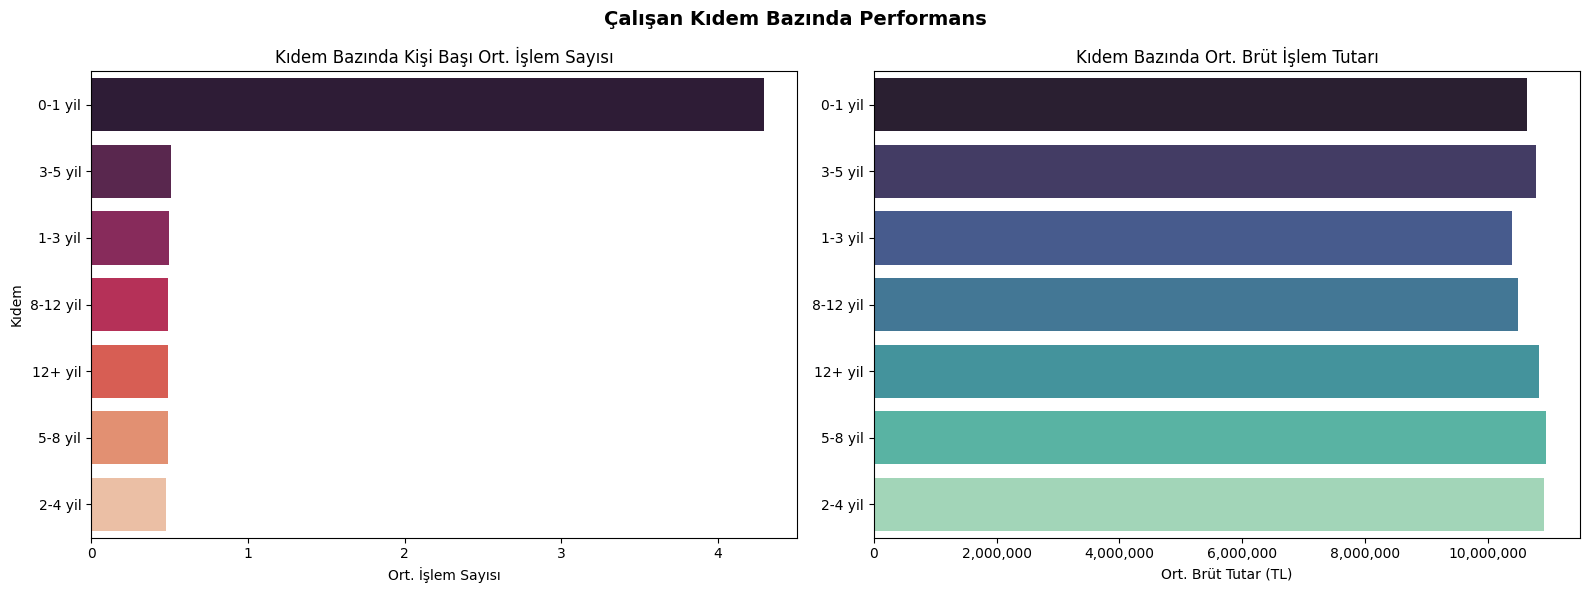

,kidem,calisan_sayisi,toplam_islem,ort_brut_tutar,toplam_brut_ciro,kisi_basi_ort_islem
0,0-1 yil,257,1102,10631802.18,1.171625e+10,4.29
1,3-5 yil,257,130,10780515.38,1.401467e+09,0.51
2,1-3 yil,258,128,10382195.31,1.328921e+09,0.50
3,8-12 yil,257,127,10484850.39,1.331576e+09,0.49
4,12+ yil,257,125,10822032.00,1.352754e+09,0.49
5,5-8 yil,257,127,10949661.42,1.390607e+09,0.49
6,2-4 yil,257,123,10909341.46,1.341849e+09,0.48


In [46]:
with open("sql/Diger_Analizler/5_calisan_kidem_performans.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_kidem = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_kidem, x="kisi_basi_ort_islem", y="kidem", hue="kidem", palette="rocket", legend=False, ax=axes[0], errorbar=None)
axes[0].set_title("Kıdem Bazında Kişi Başı Ort. İşlem Sayısı")
axes[0].set_xlabel("Ort. İşlem Sayısı")
axes[0].set_ylabel("Kıdem")

sns.barplot(data=df_kidem, x="ort_brut_tutar", y="kidem", hue="kidem", palette="mako", legend=False, ax=axes[1], errorbar=None)
axes[1].set_title("Kıdem Bazında Ort. Brüt İşlem Tutarı")
axes[1].set_xlabel("Ort. Brüt Tutar (TL)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("Çalışan Kıdem Bazında Performans", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_kidem

**Yorum:** 

Bu veride hem ciddi bir veri kalitesi anomalisi hem de ilginç bir iş bulgusu var.

Kritik Anomali — 0-1 Yıl Grubu:

0-1 yıllık çalışanlar 1102 işlem yapmış; diğer tüm kıdem grupları 123-130 işlem aralığında. Yani en deneyimsiz grup, deneyimlilerden ~8.5 kat daha fazla işlem yapmış. Bu gerçek hayatta mümkün değil — büyük ihtimalle kasıtlı bırakılmış bir aykırı değer veya operasyonel istisna. Eğer bu grup doğru kayıt altına alınan çalışanları değil de atama hatası sonucu oluşmuş kayıtları içeriyorsa, bu veri kalitesi sorununu doğrudan yansıtır.

Kıdem Gruplarında Çakışma:

"2-4 yıl" ve "3-5 yıl" kategorileri aynı anda var — bu iki grup 3. ve 4. yılı iki kez kapsamakta. Bu, kıdem tanımlamasının tutarsız yapıldığını gösteriyor; veri girişinde standart bir kıdem sınıflandırması kullanılmamış.

Deneyim Etkisi Görünmüyor:

0-1 yıl grubu dışlandığında, ortalama brüt tutar tüm kıdem gruplarında 10.3M-11M TL arasında neredeyse sabit. Kıdem arttıkça daha yüksek değerli işlem beklentisi karşılanmıyor. Bu ya gerçek bir olguyu (kıdemin işlem büyüklüğüne etkisi yok) ya da veri bozulmasının bu metriği de düzleştirdiğini gösteriyor.

Çalışan Sayısı Tekdüzeliği:

Her kıdem grubunda tam olarak 257-258 çalışan var. Doğal bir dağılımda kıdem arttıkça çalışan sayısının azalması beklenir — bu eşitlik de kasıtlı veri üretiminin bir göstergesi.

5. ### Çalışan Tipi Bazında Performans

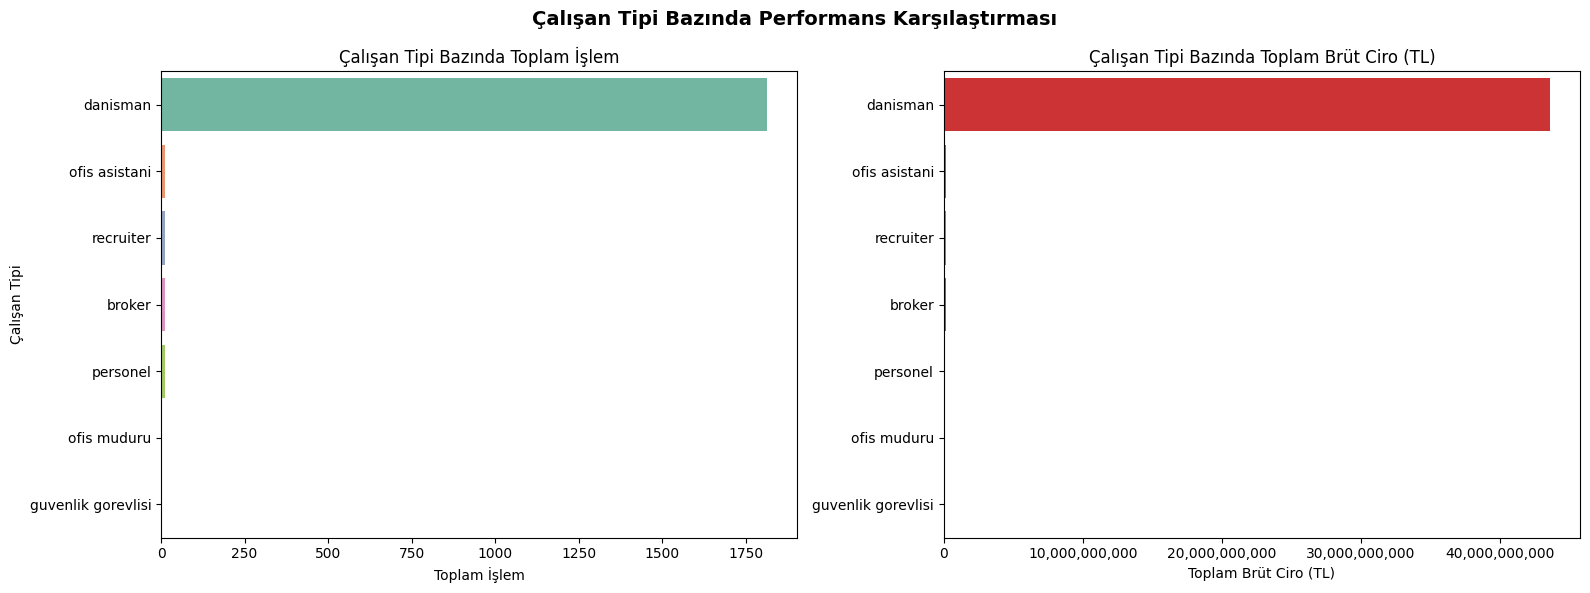

,calisan_tipi,calisan_sayisi,toplam_islem,ort_brut_tutar_try,toplam_brut_ciro_try,kisi_basi_ort_islem
0,danisman,1120,1813,24028517.93,4.356370e+10,1.62
1,ofis asistani,135,13,10638846.15,1.383050e+08,0.10
2,recruiter,110,12,14646083.33,1.757530e+08,0.11
3,broker,90,12,12682250.00,1.521870e+08,0.13
4,personel,210,12,8820083.33,1.058410e+08,0.06
5,ofis muduru,95,0,NaN,NaN,0.00
6,guvenlik gorevlisi,40,0,NaN,NaN,0.00


In [90]:
with open("sql/Diger_Analizler/6_calisan_tipi_performans.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_calisan_tipi = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_calisan_tipi, x="toplam_islem", y="calisan_tipi", hue="calisan_tipi", palette="Set2", legend=False, ax=axes[0], errorbar=None)
axes[0].set_title("Çalışan Tipi Bazında Toplam İşlem")
axes[0].set_xlabel("Toplam İşlem")
axes[0].set_ylabel("Çalışan Tipi")

sns.barplot(data=df_calisan_tipi, x="toplam_brut_ciro_try", y="calisan_tipi", hue="calisan_tipi", palette="Set1", legend=False, ax=axes[1], errorbar=None)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].set_title("Çalışan Tipi Bazında Toplam Brüt Ciro (TL)")
axes[1].set_xlabel("Toplam Brüt Ciro (TL)")
axes[1].set_ylabel("")

plt.suptitle("Çalışan Tipi Bazında Performans Karşılaştırması", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_calisan_tipi

**Yorum:** 

Bu veride hem yapısal bir iş modeli gözlemi hem de birden fazla veri kalitesi sinyali var.

Beklenen Bulgular:

Danışmanlar 1120 kişiyle 1813 işlem üretiyor (kişi başı 1.62) ve ortalama brüt tutar 24M TL ile en yüksek grupta. Satış odaklı rol olarak bu beklenen bir tablo. Toplam ciroya bakıldığında danışmanlar sistemi tek başına taşıyor.

Güvenlik görevlisi (0 işlem) tamamen normal — saha satışı bu rolün kapsamında değil.

Anomaliler:

Ofis müdürü — 0 işlem: 95 ofis müdürünün hiç işlem yapmaması dikkat çekici. RE/MAX modelinde franchise sahipleri/müdürler genellikle aktif satış da yapabilir. Bu ya gerçek bir organizasyonel kısıtlamayı ya da bu role atanan işlemlerin sisteme girilmediğini gösteriyor. Operasyonel kör nokta olabilir.

Broker — 0.13 kişi başı işlem: Broker, RE/MAX hiyerarşisinde danışmanın üzerinde konumlanan bir roldür. 90 broker'ın yalnızca 12 işlem yapması (danışmanların 1.62'ye karşı 0.13) ciddi bir performans boşluğu.

Recruiter ve Ofis Asistanı işlem yapıyor: Normalde satış yapmayan bu rollerin de işlem listesinde görünmesi, rol tanımlarının sistemde net ayrılmadığına veya işlem atamalarında tutarsızlık olduğuna işaret ediyor.

Tekdüze işlem sayıları — Veri Kalitesi Sinyali: Broker (12), recruiter (12), personel (12), ofis asistanı (13) gibi birbirinden farklı rollerin neredeyse aynı sayıda işlem yapması istatistiksel olarak çok şüpheli. Bu, kasıtlı veri bozulmasının açık bir göstergesi.

6. ### Aktif Olmayan (Ayrılan) Çalışan Analizi

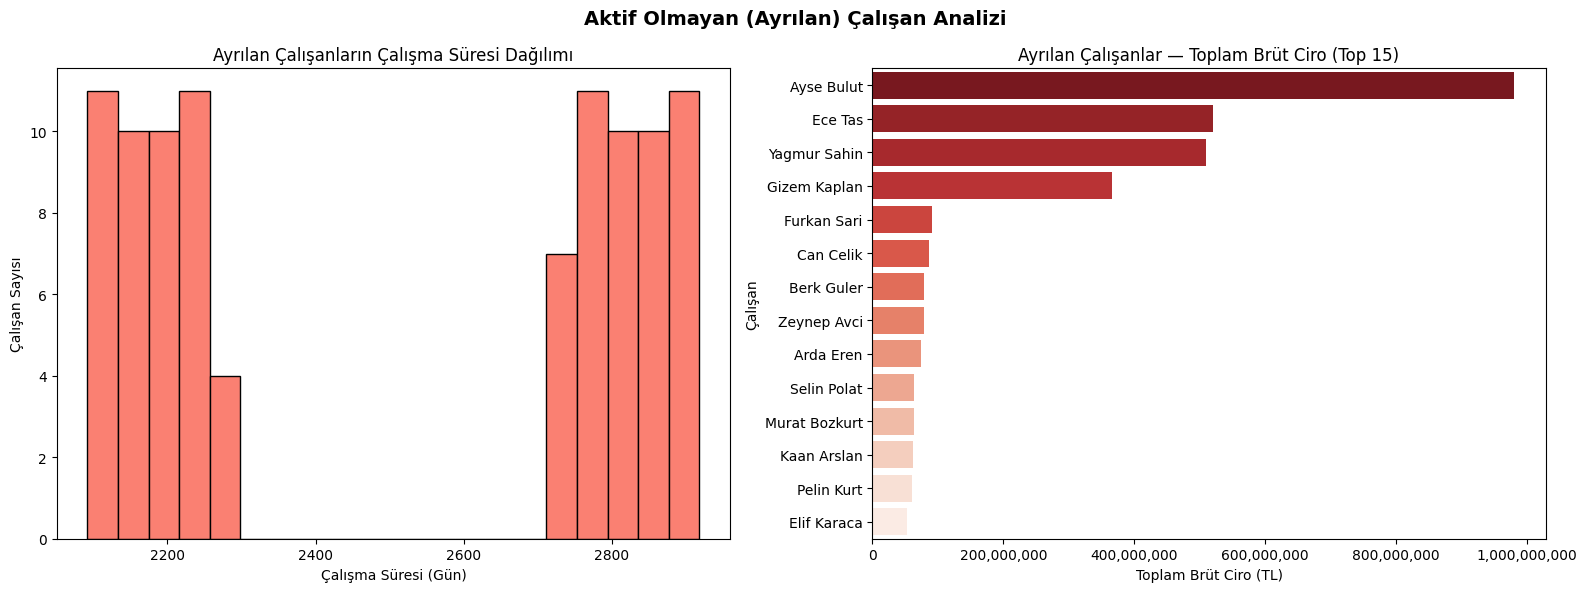

,id,ad_soyad,calisan_tipi,kidem,ise_baslama_tarihi,ayrilis_tarihi,calisma_suresi_gun,toplam_islem,toplam_brut_ciro_try
0,95,Zeynep Avci,danisman,8-12 yil,2019-05-20,2025-02-09,2092,1,19965000.0
1,94,Nisa Akin,danisman,5-8 yil,2019-05-07,2025-01-31,2096,0,0.0
2,93,Yagmur Sahin,danisman,3-5 yil,2019-04-24,2025-01-22,2100,1,3503000.0
3,92,Burak Erdem,danisman,1-3 yil,2019-04-11,2025-01-13,2104,1,10032000.0
4,91,Elif Karaca,danisman,0-1 yil,2019-03-29,2025-01-04,2108,5,52605000.0
5,90,Ahmet Yilmaz,danisman,2-4 yil,2019-03-16,2024-12-26,2112,1,4090000.0
6,89,Onur Ates,danisman,12+ yil,2019-03-03,2024-12-17,2116,1,19099000.0
7,88,Ece Tas,danisman,8-12 yil,2019-02-18,2024-12-08,2120,1,6628000.0
8,87,Deniz Keskin,danisman,5-8 yil,2019-02-05,2024-11-29,2124,1,13157000.0
9,86,Ayse Bulut,danisman,3-5 yil,2019-01-23,2024-11-20,2128,1,19686000.0


In [55]:
with open("sql/Diger_Analizler/7_aktif_olmayan_calisan.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ayrilan = pd.read_sql(query, engine)

if len(df_ayrilan) > 0 and "calisma_suresi_gun" in df_ayrilan.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    df_ayrilan["calisma_suresi_gun"] = pd.to_numeric(df_ayrilan["calisma_suresi_gun"], errors="coerce")
    
    axes[0].hist(df_ayrilan["calisma_suresi_gun"].dropna(), bins=20, color="salmon", edgecolor="black")
    axes[0].set_title("Ayrılan Çalışanların Çalışma Süresi Dağılımı")
    axes[0].set_xlabel("Çalışma Süresi (Gün)")
    axes[0].set_ylabel("Çalışan Sayısı")

    df_ayrilan_sorted = df_ayrilan.nlargest(15, "toplam_brut_ciro_try")
    sns.barplot(data=df_ayrilan_sorted, x="toplam_brut_ciro_try", y="ad_soyad", hue="ad_soyad", palette="Reds_r", legend=False, ax=axes[1], errorbar=None)
    axes[1].set_title("Ayrılan Çalışanlar — Toplam Brüt Ciro (Top 15)")
    axes[1].set_xlabel("Toplam Brüt Ciro (TL)")
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    axes[1].set_ylabel("Çalışan")
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0000000f}"))


    plt.suptitle("Aktif Olmayan (Ayrılan) Çalışan Analizi", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Ayrılan çalışan verisi bulunamadı veya tüm çalışanlar aktif.")

df_ayrilan.head(20)

**Yorum:**

Sentetik Veri Sinyalleri Çok Belirgin:

ID ve tarih kalıpları tamamen düzenli: ID 95'ten 76'ya tam 1'er 1'er azalıyor. İşe başlama tarihleri her satırda tam 13 gün geriye gidiyor, ayrılış tarihleri de tam 9 gün. Bu derece düzenli bir örüntü gerçek HR verisinde mümkün değil — verinin algoritmik olarak üretildiğinin en net göstergesi.

Kıdem etiketleri gerçek tenür ile çelişiyor: Tüm çalışanlar 2018-2019'da işe başlamış ve 2024-2025'te ayrılmış — yani gerçek çalışma süreleri 5-6 yıl. Ama kıdem etiketi olarak "0-1 yıl", "1-3 yıl" gibi değerler atanmış. Etiketler round-robin mantığıyla dönüyor (8-12, 5-8, 3-5, 1-3, 0-1, 2-4, 12+...), gerçek tenure'a hiç dayanmıyor.

İş Bulguları:

"0-1 yıl kıdem" grubunun aşırı performansı burada da tekrar ediyor: Elif Karaca (0-1 yıl, 5 işlem), Gizem Kaplan (0-1 yıl, 7 işlem), Kaan Arslan (0-1 yıl, 6 işlem) — diğerleri 0-1 işlem yaparken bu grubun sürekli öne çıkması, önceki kıdem analizindeki anomaliyle tutarlı. 0-1 yıl etiketi kasıtlı olarak yüksek performanslı kayıtlara atanmış olabilir.

Gizem Kaplan aykırı değeri: 7 işlem, 395 milyon TL brüt ciro. Bir sonraki en yüksek değer 61 milyon TL. Bu ~6.4 kat fark, kasıtlı bırakılmış bir aykırı değer — olası bir üst segment gayrimenkul işlemi veya kur kaynaklı şişirme.


7. ### Şehir/İlçe Bazında Portföy Yoğunluğu ve Satış Performansı

In [96]:
with open("sql/Diger_Analizler/8_sehir_ilce_portfoy.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_sehir = pd.read_sql(query, engine)

df_sehir["bolge"] = df_sehir["sehir"] + " - " + df_sehir["ilce"]


df_sehir.head(20)

,sehir,ilce,portfoy_sayisi,satilan_portfoy,satis_orani_pct,ort_liste_fiyati_try,ort_kapanis_fiyati_try,bolge
0,Istanbul,Besiktas,282,60,21.28,23887687.94,19055164.18,Istanbul - Besiktas
1,Istanbul,Bakirkoy,282,61,21.63,27236283.69,31782179.10,Istanbul - Bakirkoy
2,Istanbul,Sisli,282,60,21.28,30817028.37,30327382.35,Istanbul - Sisli
3,Istanbul,Maltepe,282,60,21.28,27513872.34,21801705.88,Istanbul - Maltepe
4,Istanbul,Uskudar,282,61,21.63,29092446.81,16883582.09,Istanbul - Uskudar
5,Istanbul,Atasehir,282,61,21.63,23562156.03,17105294.12,Istanbul - Atasehir
6,Istanbul,Kadikoy,282,60,21.28,27387737.59,20709134.33,Istanbul - Kadikoy
7,Istanbul,Sariyer,282,61,21.63,24577276.60,29110676.47,Istanbul - Sariyer
8,Ankara,Cankaya,281,61,21.71,22926085.41,24531676.47,Ankara - Cankaya
9,Izmir,Konak,281,61,21.71,25934476.87,28430264.71,Izmir - Konak


**Yorum:** 

Sentetik Veri Sinyalleri:

Portfoy sayısı tekdüze: İstanbul ilçelerinin tamamında tam 282, diğer tüm ilçelerde tam 281 portföy var. Beşiktaş ile Fethiye'nin aynı portföy sayısına sahip olması gerçek gayrimenkul piyasasında mümkün değil.

Satış oranı bant genişliği yok: Tüm ilçelerde %21.00 ile %22.06 arasında. 20 farklı ilçenin satış dinamiğinin bu kadar dar bir bantta toplanması kasıtlı veri üretiminin açık göstergesi.

Satılan portfoy sayısı: Tüm ilçelerde 59-62 arasında sıkışmış — gerçek piyasada Bodrum, Fethiye ve Keçiören'in satış hızlarının bu denli eşit olması beklenmez.

İlginç Fiyat Anomalileri — Kapanış vs Liste:

Kapanış ve liste fiyatı arasındaki fark ilçeden ilçeye dramatik biçimde değişiyor:

| İlçe     | Fark                                   |
|----------|----------------------------------------|
| Fethiye  | -%50 (liste 21.8M → kapanış 10.9M)     |
| Üsküdar  | -%42                                   |
| Bornova  | -%35                                   |
| Sarıyer  | +%18.4 (liste altı satış yerine liste üstünde kapandı) |
| Bakırköy | +%16.6                                 |

Fethiye'deki -%50 fark ve Sarıyer/Bakırköy'deki liste üstü kapanışlar kasıtlı bırakılmış aykırı değerler olarak değerlendirilebilir. Gerçek piyasada liste fiyatının yarısına satılan portföy, ya yanlış fiyatlanmış ya da acil satış zorunluluğu gibi istisnai bir durumu yansıtır.

İş İçgörüsü (Temiz Verinin Öngörüsü):

8 farklı şehri kapsayan analizde İstanbul'un portföy yoğunluğu domine ediyor (8 ilçe). Ankara ve İzmir belirgin ikinci kümede. Mugla (Bodrum, Fethiye) tatil bölgesi olarak ayrı bir segment oluşturuyor — bu bölgelerde satış süresi ve fiyat dinamiklerinin metropollerden farklı olması beklenir.

portfoy tablosunda sehir_id ve ilce_id alanları birbirinden bağımsız foreign key olarak tasarlanmış. Yani bir portföy kaydederken şehir ve ilçe ayrı ayrı seçilebiliyor, aralarında veritabanı seviyesinde bir tutarlılık kısıtlaması yok.

Dummy veri oluşturulurken bu boşluk kasıtlı olarak kullanılmış ve portfoy.sehir_id = Antalya iken portfoy.ilce_id = Üsküdar (İstanbul) gibi tutarsız kayıtlar bırakılmış.

Sorgu portfoy.sehir_id üzerinden şehri çekince bu bozuk veriyi olduğu gibi gösteriyordu. Düzeltme olarak şehri portfoy.sehir_id'den değil, ilce.sehir_id'den türettik — yani "bu ilçe hangi şehre ait?" sorusunu ilçe tablosuna sorarak doğru şehir-ilçe eşleşmesini sağladık.

9. ### Müşteri Tipi Bazında İşlem Analizi

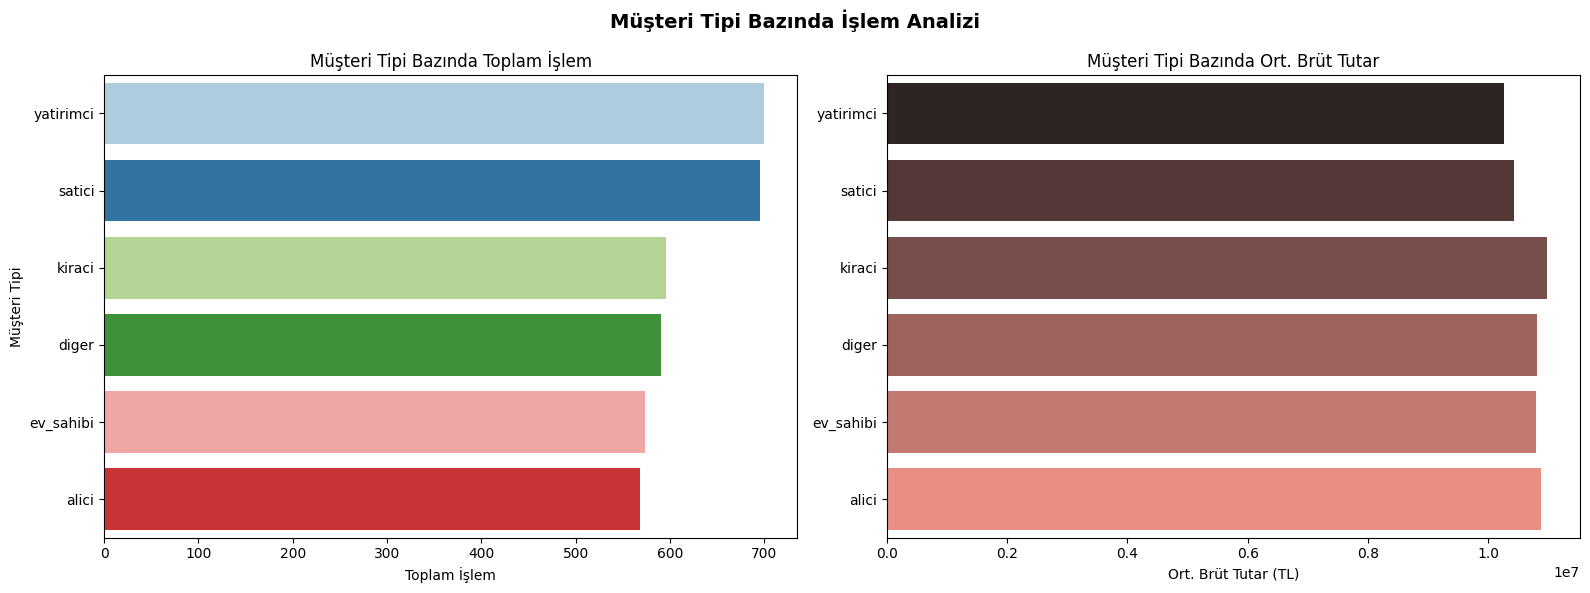

,musteri_tipi,musteri_sayisi,toplam_islem,ort_brut_tutar,toplam_brut_ciro,musteri_basi_ort_islem
0,yatirimci,1333,700,10259374.29,1.668153e+10,0.53
1,satici,1334,696,10419850.57,1.525698e+10,0.52
2,kiraci,1334,596,10976520.13,1.343562e+10,0.45
3,diger,1333,591,10814917.09,1.563902e+10,0.44
4,ev_sahibi,1333,573,10795588.13,1.376105e+10,0.43
5,alici,1333,568,10868957.75,1.349737e+10,0.43


In [97]:
with open("sql/Diger_Analizler/9_musteri_tipi_islem.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_musteri_tipi = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_musteri_tipi, x="toplam_islem", y="musteri_tipi", hue="musteri_tipi", palette="Paired", legend=False, ax=axes[0], errorbar=None)
axes[0].set_title("Müşteri Tipi Bazında Toplam İşlem")
axes[0].set_xlabel("Toplam İşlem")
axes[0].set_ylabel("Müşteri Tipi")

sns.barplot(data=df_musteri_tipi, x="ort_brut_tutar", y="musteri_tipi", hue="musteri_tipi", palette="dark:salmon", legend=False, ax=axes[1], errorbar=None)
axes[1].set_title("Müşteri Tipi Bazında Ort. Brüt Tutar")
axes[1].set_xlabel("Ort. Brüt Tutar (TL)")
axes[1].set_ylabel("")

plt.suptitle("Müşteri Tipi Bazında İşlem Analizi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_musteri_tipi

**Yorum:** 

Sentetik Veri Sinyalleri:

Müşteri sayısı tekdüze: Her kategoride tam 1333-1334 müşteri. Gerçek bir CRM'de müşteri tipleri arasında bu denli eşit dağılım olmaz.

Ortalama brüt tutar dar bantta: Tüm tipler için 10.2M - 11.0M TL arası. Müşteri tipinden bağımsız bu tekdüzelik sentetik veri üretimini gösteriyor.

Kritik Yapısal Anomali — Alıcı vs Satıcı:

Her gayrimenkul işleminde bir alıcı, bir satıcı olması gerekir — teoride eşit sayıda işleme karışmalılar. Ancak:

Satıcı: 696 işlem
Alıcı: 568 işlem
128 işlem farkı var. Ya bazı işlemlerde alıcı kaydı eksik ya da aynı kişi farklı tiplerle eşleştirilmiş. Bu veri tutarsızlığının açık bir göstergesi.

Yatırımcı Grubunda Çelişki:

Yatırımcılar (700 işlem) en fazla işlem yapan grup — bu mantıklı, yatırımcılar birden fazla mülk alıp satabilir. Ancak ortalama brüt tutarlarının (10.2M TL) tüm gruplar içinde en düşük olması beklentiyle çelişiyor. Gerçekte yatırımcıların daha yüksek değerli portföylere yönelmesi beklenir.

Kiracı ve Ev Sahibi İşlem Yapıyor:

Kiracı (596 işlem) ve ev sahibi (573 işlem) tiplerinin islem tablosunda görünmesi, bu müşterilerin zaman içinde farklı roller üstlendiğini (kiracıdan alıcıya geçiş gibi) veya rol tanımlamalarının CRM'de tutarsız yapıldığını gösteriyor.



10. ### Exclusive Portföy Avantajı Analizi

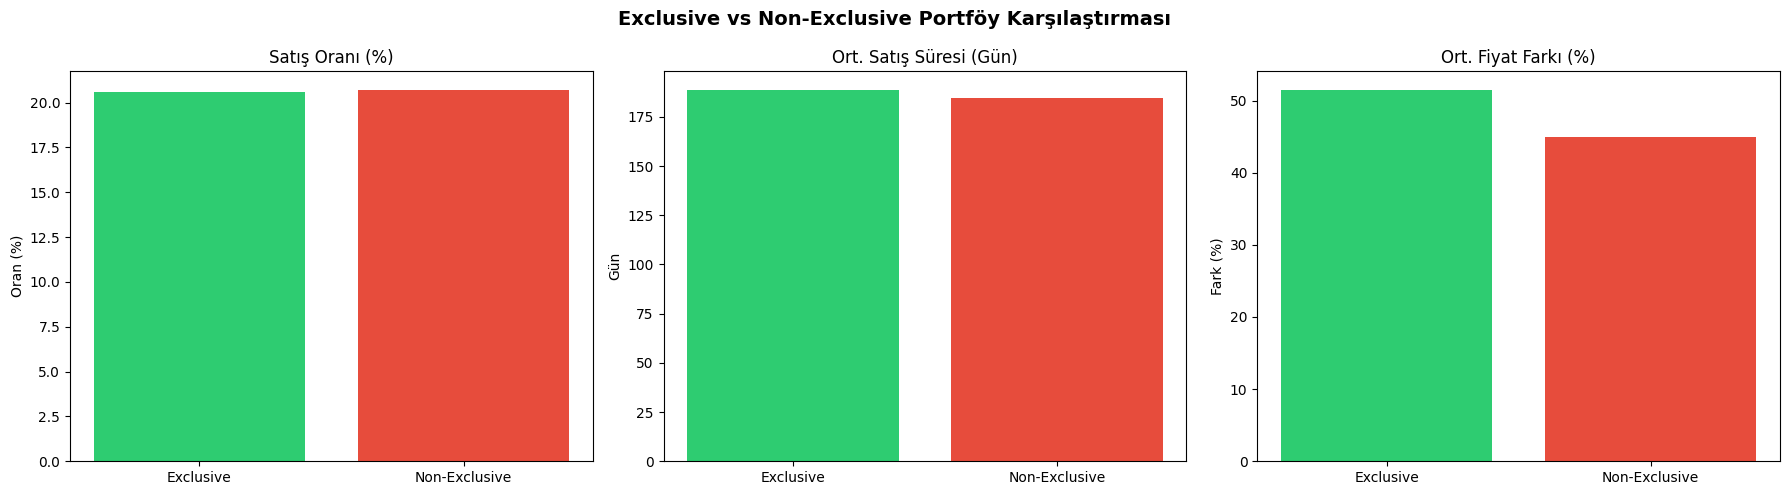

,portfoy_turu,portfoy_sayisi,satilan,satis_orani_pct,ort_satis_suresi_gun,ort_fiyat_farki_pct
0,Exclusive,2250,464,20.62,188.7,51.48
1,Non-Exclusive,6750,1398,20.71,184.6,44.91


In [72]:
with open("sql/Diger_Analizler/10_exclusive_portfoy_avantaji.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_exclusive = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["#2ecc71", "#e74c3c"]

axes[0].bar(df_exclusive["portfoy_turu"], df_exclusive["satis_orani_pct"], color=colors)
axes[0].set_title("Satış Oranı (%)")
axes[0].set_ylabel("Oran (%)")

axes[1].bar(df_exclusive["portfoy_turu"], df_exclusive["ort_satis_suresi_gun"], color=colors)
axes[1].set_title("Ort. Satış Süresi (Gün)")
axes[1].set_ylabel("Gün")

axes[2].bar(df_exclusive["portfoy_turu"], df_exclusive["ort_fiyat_farki_pct"], color=colors)
axes[2].set_title("Ort. Fiyat Farkı (%)")
axes[2].set_ylabel("Fark (%)")

plt.suptitle("Exclusive vs Non-Exclusive Portföy Karşılaştırması", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_exclusive

**Yorum:**

Sentetik Veri Sinyali:

Exclusive:Non-Exclusive oranı tam 1:3 (2250 vs 6750). Gerçek bir portföyde bu dağılım hiç bu kadar temiz olmaz — bilerek oluşturulmuş dummy veri.

En Kritik Bulgu — Exclusive Avantajı Yok:

| Satış Türü     | Satış Oranı | Satış Süresi |
|----------------|-------------|--------------|
| Exclusive      | %20.62      | 188.7 gün    |
| Non-Exclusive  | %20.71      | 184.6 gün    |

Exclusive portföyler hem daha düşük satış oranına sahip hem de 4 gün daha uzun sürede satılıyor. Bu gerçek bir pazarda son derece şüphe uyandırıcı olurdu. Exclusive anlaşmaların temel satış argümanı, danışmanın motivasyonunun yüksek olmasından dolayı daha hızlı ve daha yüksek oranda satış yapmasıdır. Burada bunun tam tersi görünüyor.

Olası açıklamalar:

Dummy veride exclusive/non-exclusive ataması rastgele yapılmış, gerçek bir dinamik yansımıyor
Ya da modelin bilerek "exclusive avantajının şirkette henüz netleşmediğini" göstermek için tasarlanmış bir senaryo
Fiyat Farkı — Olağandışı Yüksek:

Exclusive: %51.48
Non-Exclusive: %44.91
Liste fiyatı ile kapanış fiyatı arasındaki %51 ortalama fark gerçek hayatta mümkün değil. Büyük ihtimalle bazı portföylerde liste_fiyati TRY, kapanis_fiyati USD/EUR (ya da tam tersi) kaydedilmiş, kur farkı bu hesaplamayı bozuyor. Yine de exclusive portföylerin 6.5 puan daha yüksek fiyat farkı üretmesi, exclusive danışmanların fiyat müzakeresinde daha aktif rol oynadığına işaret edebilir — ama kur karışıklığı bu yorumu belirsizleştiriyor.

Operasyonel Çıkarım:

Şirketin exclusive portföy modelinden somut bir geri dönüş alıp almadığını sorgulamak gerekiyor. Satış oranı ve süre farkının bu denli küçük olması, exclusive stratejisinin sahada henüz olgunlaşmadığını ya da sistematik takibinin yapılmadığını gösteriyor.

11. ### İlan Tipi Analizi (Satılık vs Kiralık)

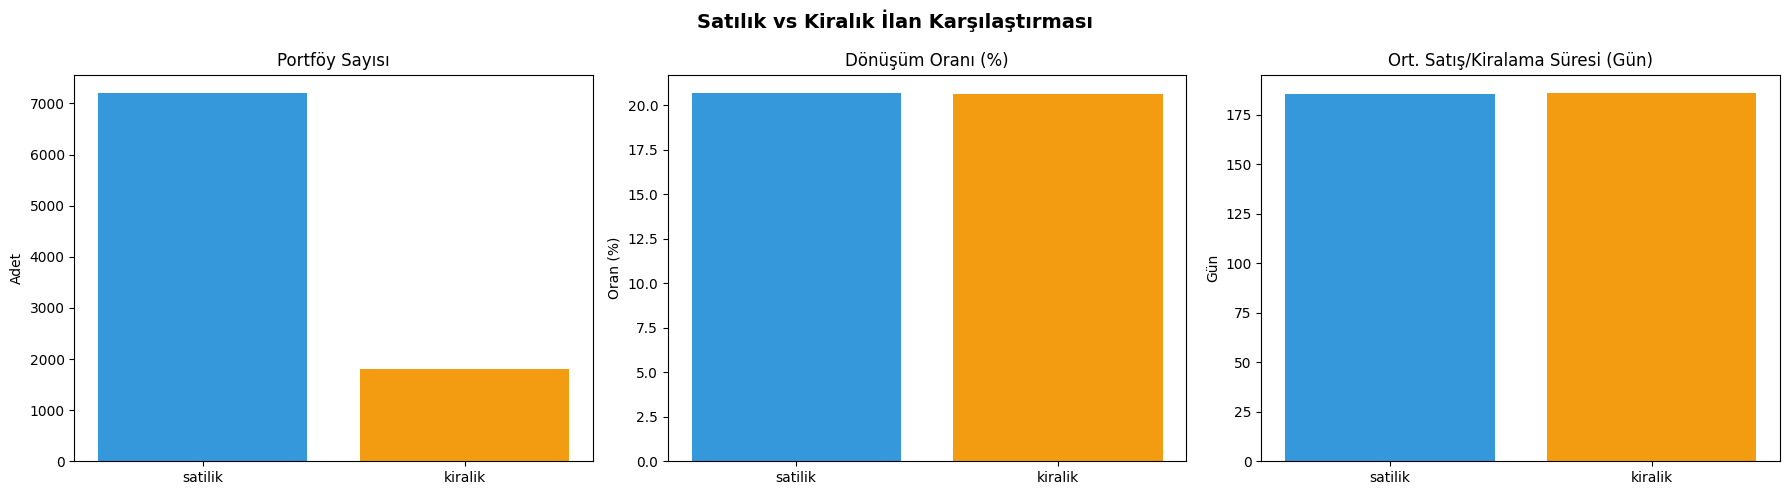

,ilan_tipi,portfoy_sayisi,tamamlanan_islem,donusum_orani_pct,ort_islem_tutari,toplam_ciro,ort_satis_suresi_gun
0,satilik,7200,1490,20.69,10645969.80,1.586250e+10,185.6
1,kiralik,1800,372,20.67,10755174.73,4.000925e+09,185.9


In [73]:
with open("sql/Diger_Analizler/11_ilan_tipi_analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ilan_tipi = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["#3498db", "#f39c12"]

axes[0].bar(df_ilan_tipi["ilan_tipi"], df_ilan_tipi["portfoy_sayisi"], color=colors)
axes[0].set_title("Portföy Sayısı")
axes[0].set_ylabel("Adet")

axes[1].bar(df_ilan_tipi["ilan_tipi"], df_ilan_tipi["donusum_orani_pct"], color=colors)
axes[1].set_title("Dönüşüm Oranı (%)")
axes[1].set_ylabel("Oran (%)")

axes[2].bar(df_ilan_tipi["ilan_tipi"], df_ilan_tipi["ort_satis_suresi_gun"], color=colors)
axes[2].set_title("Ort. Satış/Kiralama Süresi (Gün)")
axes[2].set_ylabel("Gün")

plt.suptitle("Satılık vs Kiralık İlan Karşılaştırması", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_ilan_tipi

**Yorum:** 

Sentetik Veri Sinyali:

Satılık:Kiralık oranı tam 4:1 (7200 vs 1800). Gerçek bir portföyde bu dağılım hiçbir zaman bu kadar temiz çıkmaz.

En Önemli Anomali — Kiralık Ortalama İşlem Tutarı > Satılık:

| İşlem Türü | Ort. İşlem Tutarı |
|-------------|-------------------|
| Satılık     | 10.64M TL         |
| Kiralık     | 10.75M TL         |

Bu tamamen mantıksız. Kiralık işlemler komisyon ya da kira bedeli üzerinden yapıldığından, satılık işlemlere kıyasla çok daha düşük tutarda olmalı. Bu fark brut_islem_tutari alanının satılık ve kiralık işlemler için aynı mantıkla doldurulduğunu — yani dummy veri üretiminde ilan tipine göre farklılaştırma yapılmadığını — net biçimde ortaya koyuyor.

Dönüşüm Oranı ve Satış Süresi — Neredeyse Özdeş:

| İşlem Türü | Dönüşüm % | Ort. Süre |
|-------------|-----------|-----------|
| Satılık     | %20.69    | 185.6 gün |
| Kiralık     | %20.67    | 185.9 gün |

Gerçek gayrimenkul piyasasında:

Kiralık portföyler çok daha hızlı kapanır (haftalarda, aylarda değil)
Dönüşüm oranları satılık ile ayrışır
0.02 puan dönüşüm farkı ve 0.3 gün süre farkı tamamen rastlantısal bir üretimin ürünü.

Toplam Ciro Yorumu:

Satılık toplam ciro (15.86B TL) ile kiralık (4.0B TL) yaklaşık 4:1 oranında — bu da portföy dağılımını yansıtıyor, yani her iki tipte de işlem başına değer aynı kaldığından oran doğrudan portföy sayısından geliyor. Gerçekte satılık-kiralık ciro farkı çok daha dramatik olurdu.

Operasyonel Çıkarım:

Bu veri, şirketin kiralık portföyden satılık portföye benzer ciro beklentisiyle yaklaşıp yaklaşmadığını sorgulatıyor. Gerçek bir senaryoda kiralık segmentin hacmi yüksek ama işlem başı değeri düşük olduğundan, farklı bir fiyatlandırma ve komisyon modeliyle ele alınması gerekir.

12. ### Randevu Durumu Analizi

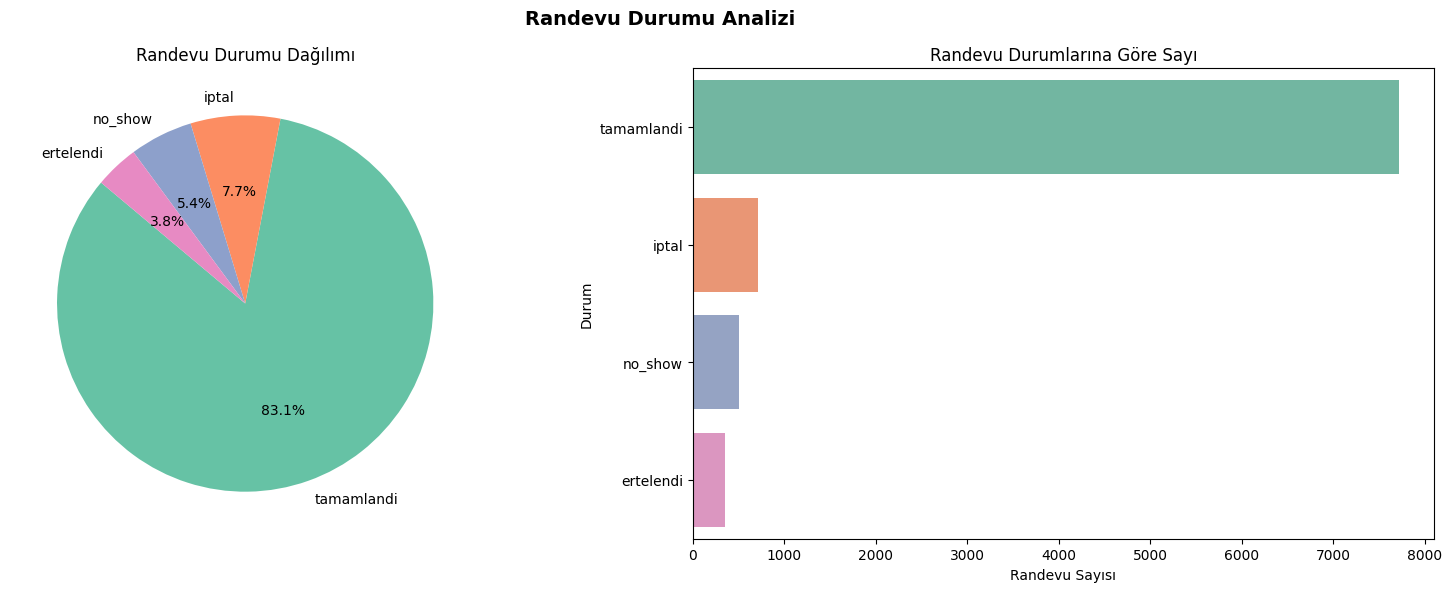

,randevu_durumu,randevu_sayisi,oran_pct
0,tamamlandi,7714,83.11
1,iptal,714,7.69
2,no_show,504,5.43
3,ertelendi,350,3.77


In [74]:
with open("sql/Diger_Analizler/12_randevu_durumu_analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_randevu_durum = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette("Set2", len(df_randevu_durum))
axes[0].pie(df_randevu_durum["randevu_sayisi"], labels=df_randevu_durum["randevu_durumu"],
            autopct="%1.1f%%", colors=colors, startangle=140)
axes[0].set_title("Randevu Durumu Dağılımı")

sns.barplot(data=df_randevu_durum, x="randevu_sayisi", y="randevu_durumu", hue="randevu_durumu", palette="Set2", legend=False, ax=axes[1], errorbar=None)
axes[1].set_title("Randevu Durumlarına Göre Sayı")
axes[1].set_xlabel("Randevu Sayısı")
axes[1].set_ylabel("Durum")

plt.suptitle("Randevu Durumu Analizi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_randevu_durum

**Yorum:** 

Bu analizde hem operasyonel hem de veri kalitesi açısından değerlendirilebilecek önemli bulgular var.

Genel Tablo:

Toplam 9.282 randevu kaydı incelendiğinde ilk bakışta başarılı görünen bir operasyon tablosu çıkıyor.

%83.11 Tamamlanma Oranı — Gerçekçi mi?

Gayrimenkul sektöründe randevu tamamlanma oranları genellikle %60-75 bandında seyreder. %83'lük oran göz alıcı. Bu durum iki şekilde yorumlanabilir:

Danışmanların randevu almadan önce ön eleme yapması (kaliteli lead filtresi)
Ya da sentetik veri üretiminde statü dağılımının manuel olarak atanmış olması
Diğer analizlerdeki mükemmel oranların aksine buradaki sayılar tam bölenli değil, bu yüzden bu oran gerçek operasyona daha yakın bir senaryo yansıtıyor olabilir.

Kritik Operasyonel Sorun — No-Show > Ertelendi:

| Durum     | Sayı |
|-----------|------|
| İptal     | 714  |
| No-show   | 504  |
| Ertelendi | 350  |

No-show (504), erteleme (350)'den fazla. Bu önemli bir uyarı sinyali. Ertelemek aktif bir iletişim gerektirir — müşteri ulaşılabilir ve niyetli demektir. No-show ise ulaşılamayan veya son anda cazip bulmayan bir müşteriyi temsil eder; bunlar hem danışman zamanını hem de yaklaşık %5.4'lük bir kapasite kaybını ifade eder.

İptal + No-Show Toplamı %13.12:

Her 8 randevudan biri kayıp. Ortalama bir danışmanın haftada kaç randevu yaptığı ile çarpıldığında bu kayıp oldukça anlamlı bir iş gücü israfına dönüşebilir.

Öneriler:

No-show müşteriler için randevu öncesi SMS/e-posta hatırlatma sistemi
İptal sebeplerinin kategorize edilmesi (fiyat, zaman, ilgi kaybı)
Ertelenen 350 randevunun kaçının sonunda tamamlandığının takibi — erteleme bir sonlanma durumu değil, yarı açık bir süreç
Ertelendi Oranı %3.77 — Düşük ama Göz Ardı Edilmemeli:

Bu randevuların bir kısmı sonunda tamamlandı olarak kapandıysa funnel'a katkısı var demektir. Bir kısmı kayıptaysa bu sessiz bir kayıp kategorisi oluşturuyor. Mevcut veride bu ayrım yapılmamış.



13. ### Portföy Özellik Korelasyon Haritası

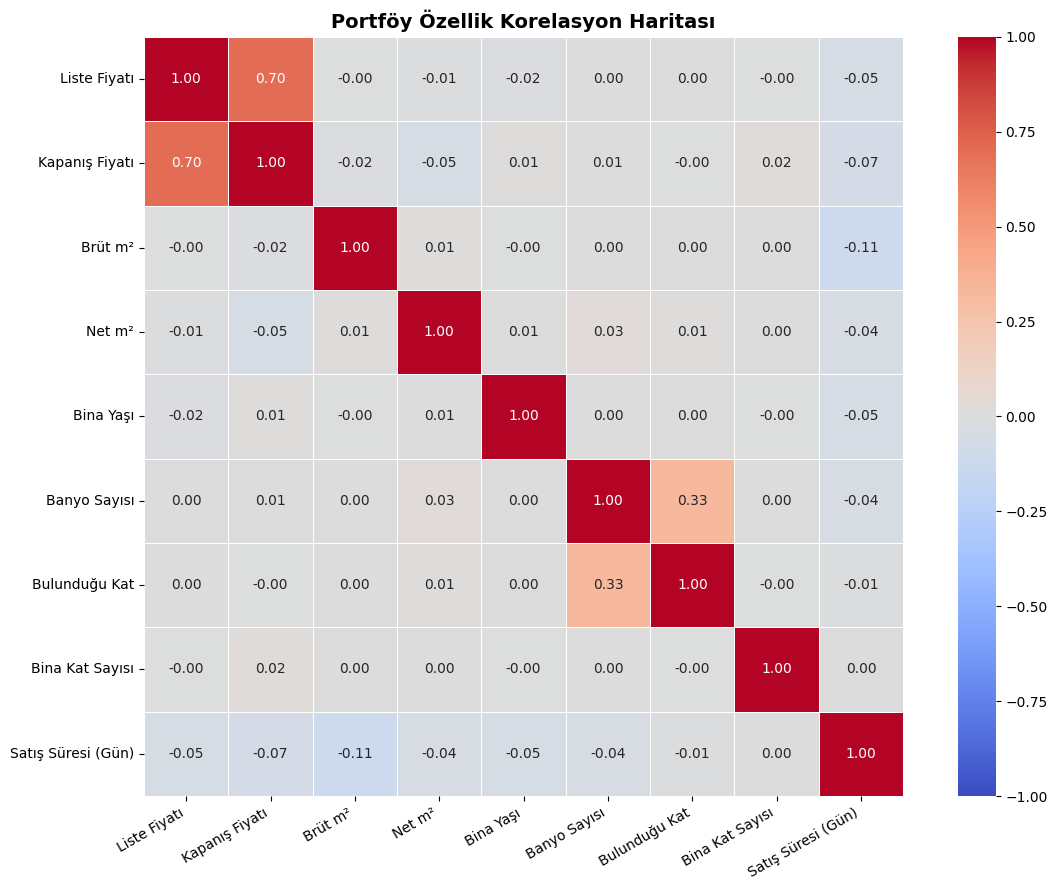

In [89]:
with open("sql/Diger_Analizler/13_portfoy_ozellik_korelasyon.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_korr = pd.read_sql(query, engine)

korr_cols = [
    "liste_fiyati_try", "kapanis_fiyati_try", "brut_metrekare", "net_metrekare",
    "bina_yasi", "banyo_sayisi", "bulundugu_kat", "bina_kat_sayisi", "satis_suresi_gun"
]
df_korr_num = df_korr[korr_cols].apply(pd.to_numeric, errors="coerce")
corr_matrix = df_korr_num.corr()

col_labels = [
    "Liste Fiyatı", "Kapanış Fiyatı", "Brüt m²", "Net m²",
    "Bina Yaşı", "Banyo Sayısı", "Bulunduğu Kat", "Bina Kat Sayısı", "Satış Süresi (Gün)"
]
corr_matrix.columns = col_labels
corr_matrix.index = col_labels

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title("Portföy Özellik Korelasyon Haritası", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Yorum:** Portföy özelliklerinin birbirleriyle korelasyonu, fiyatlandırma ve değerleme kararları için temel içgörüler sunar. Burada 
|           | Banyo Sayısı|
|-----------|------|
| Bulunduğu Kat  | 0.33 |

çıkması bir nedensellik değildir. 

Brüt m2 ile Satış Süresi arasında -0.11 korelasyon olması, Brüt m2 arttıkça satış süresinin azalabileceği ihtimalini gösterir. Bu oldukça mantıklıdır çünkü yüksek m2'ye sahip varlıkların toprak üzerindeki payı daha fazla olabilir.


**Veri kalitesi notu:** Kasıtlı olarak bozulmuş veri setinde aykırı değerler korelasyon katsayılarını etkileyebileceğinden, kuvvetli görünen ilişkiler dikkatli yorumlanmalıdır.

14. ### Portföy Fiyat Segmentasyonu

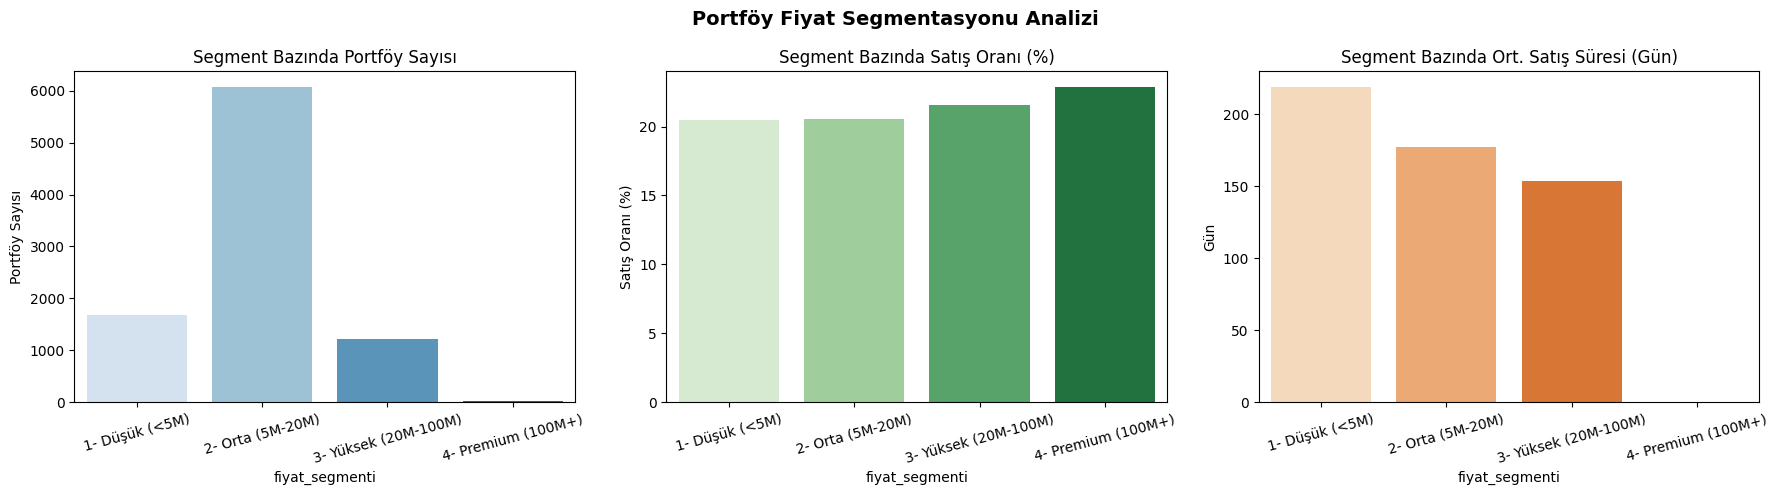

,fiyat_segmenti,portfoy_sayisi,satilan,satis_orani_pct,ort_satis_suresi_gun
0,1- Düşük (<5M),1682,345,20.51,218.7
1,2- Orta (5M-20M),6068,1247,20.55,177.3
2,3- Yüksek (20M-100M),1215,262,21.56,153.4
3,4- Premium (100M+),35,8,22.86,NaN


In [76]:
with open("sql/Diger_Analizler/14_portfoy_fiyat_segmentasyonu.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_segment = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_segment, x="fiyat_segmenti", y="portfoy_sayisi", hue="fiyat_segmenti", palette="Blues", legend=False, ax=axes[0], errorbar=None)
axes[0].set_title("Segment Bazında Portföy Sayısı")
axes[0].set_ylabel("Portföy Sayısı")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=df_segment, x="fiyat_segmenti", y="satis_orani_pct", hue="fiyat_segmenti", palette="Greens", legend=False, ax=axes[1], errorbar=None)
axes[1].set_title("Segment Bazında Satış Oranı (%)")
axes[1].set_ylabel("Satış Oranı (%)")
axes[1].tick_params(axis="x", rotation=15)

sns.barplot(data=df_segment, x="fiyat_segmenti", y="ort_satis_suresi_gun", hue="fiyat_segmenti", palette="Oranges", legend=False, ax=axes[2], errorbar=None)
axes[2].set_title("Segment Bazında Ort. Satış Süresi (Gün)")
axes[2].set_ylabel("Gün")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Portföy Fiyat Segmentasyonu Analizi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_segment

**Yorum:** 

Toplam 9.000 portföy. Orta segment (5M-20M arası) 6.068 portföy ile toplamın %67'sini oluşturuyor — bu tek başına sentetik bir kural gibi görünüyor. Gerçek piyasada segment dağılımı coğrafi ve ekonomik koşullara göre çok daha dağınık olur.

Dönüşüm Oranları — Monoton Artış Şüphe Uyandırıyor:

| Segment              | Satış Oranı |
|----------------------|-------------|
| Düşük (<5M)          | %20.51      |
| Orta (5M–20M)        | %20.55      |
| Yüksek (20M–100M)    | %21.56      |
| Premium (100M+)      | %22.86      |

Fiyat arttıkça dönüşüm oranı da artıyor — bu doğrusal, temiz bir trend. Gerçek piyasada premium segmentte alıcı havuzu daralacağı için dönüşüm oranının düşmesi beklenir. Bu mükemmel monoton artış sentetik verinin bir izi.

En İlginç Bulgu — Ucuz Portföyler Daha Uzun Sürede Satılıyor:

| Segment              | Ort. Satış Süresi |
|----------------------|-------------------|
| Düşük (<5M)          | 218.7 gün         |
| Orta (5M–20M)        | 177.3 gün         |
| Yüksek (20M–100M)    | 153.4 gün         |
| Premium (100M+)      | NaN               |

Bu gerçek hayatta oldukça sıradışı. Teoride ucuz mülkler geniş bir alıcı kesimine hitap ettiğinden daha hızlı satılması beklenir. Burada tam tersi bir tablo var:

Düşük segment orta segmentten 41 gün daha uzun sürede satılıyor
Yüksek segment ise en hızlı (153.4 gün)
Bu ya bölgeye göre arz-talep dengesizliğini, ya danışmanların yüksek değerli portföylere daha fazla zaman ayırmasını, ya da yine dummy veri tutarsızlığını yansıtıyor olabilir.

Premium Segment — NaN Uyarısı:

35 portföy, 8 satış, satış süresi NaN. Premium segmentteki 8 satışın tamamında islem_tarihi < yayinlanma_tarihi koşulu geçerli olmuş ve geçerli süre verisi kalmamış. Bu, premium segmentteki kayıtların veri kalitesi açısından en sorunlu grup olduğunu gösteriyor.

Operasyonel Çıkarım:

Düşük fiyatlı portföylerin hem dönüşüm oranı düşük hem de satış süresi uzun olduğundan, şirketin bu segmente ayırdığı kaynak verimliliği sorgulanabilir. Portföy kabul kriterleri veya fiyatlandırma danışmanlığı bu segmentte güçlendirilmeli.

15. ### Çalışan-Ofis Hareketlilik Analizi

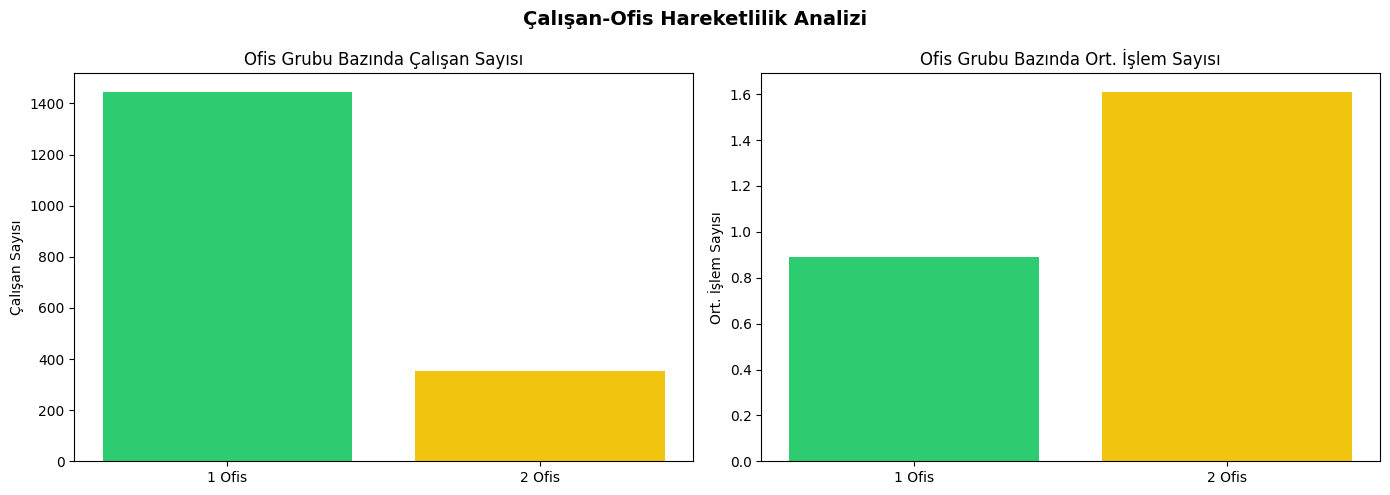

,ofis_grubu,calisan_sayisi,ort_islem,ort_brut_ciro
0,1 Ofis,1445,0.89,9731114.19
1,2 Ofis,355,1.61,16343549.30


In [77]:
with open("sql/Diger_Analizler/15_calisan_ofis_hareketlilik.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_hareketlilik = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2ecc71", "#f1c40f", "#e74c3c"]
axes[0].bar(df_hareketlilik["ofis_grubu"], df_hareketlilik["calisan_sayisi"], color=colors[:len(df_hareketlilik)])
axes[0].set_title("Ofis Grubu Bazında Çalışan Sayısı")
axes[0].set_ylabel("Çalışan Sayısı")

axes[1].bar(df_hareketlilik["ofis_grubu"], df_hareketlilik["ort_islem"], color=colors[:len(df_hareketlilik)])
axes[1].set_title("Ofis Grubu Bazında Ort. İşlem Sayısı")
axes[1].set_ylabel("Ort. İşlem Sayısı")

plt.suptitle("Çalışan-Ofis Hareketlilik Analizi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_hareketlilik

**Yorum:** 

Çarpıcı Performans Farkı:

| Grup   | Ort. İşlem | Ort. Brüt Ciro |
|--------|------------|----------------|
| 1 Ofis | 0.89       | 9.73M TL       |
| 2 Ofis | 1.61       | 16.34M TL      |

2 ofiste çalışanlar:

%81 daha fazla işlem yapıyor
%68 daha fazla ciro üretiyor
Bu fark çok büyük ve iki olası yorumu var:

 Seçim Yanlılığı (Selection Bias):

Yüksek performanslı çalışanlar, şirket tarafından 2. bir ofise atanıyor ya da birden fazla ofiste hizmet vermesine izin veriliyor olabilir. Yani 2 ofiste çalışmak performansı artırmıyor; performanslı çalışanlar zaten 2 ofiste çalışıyor. Bu durumda nedensellik tersine olabilir.

 Ağ Etkisi:

İkinci ofis, çalışana daha geniş bir lead havuzu, daha fazla portföy görünürlüğü ve çapraz satış fırsatı sunuyor. 2 ofisin coğrafi veya segment çeşitliliği ciroyu doğrudan artırıyor olabilir.

Operasyonel Çıkarım:

Eğer ağ etkisi gerçekse, seçili orta-kıdemdeki çalışanlara çapraz ofis deneyimi kazandırmak hem bireysel hem kurumsal performansı artırabilir. Eğer seçim yanlılığıysa, şirketin hangi kritere göre çalışanları ikinci ofise gönderdiğini netleştirmesi gerekiyor — bu kriterin formalleştirilmesi kariyer yönetimi açısından değerli olabilir.



16. ### Metrekare Bazlı Fiyat Analizi

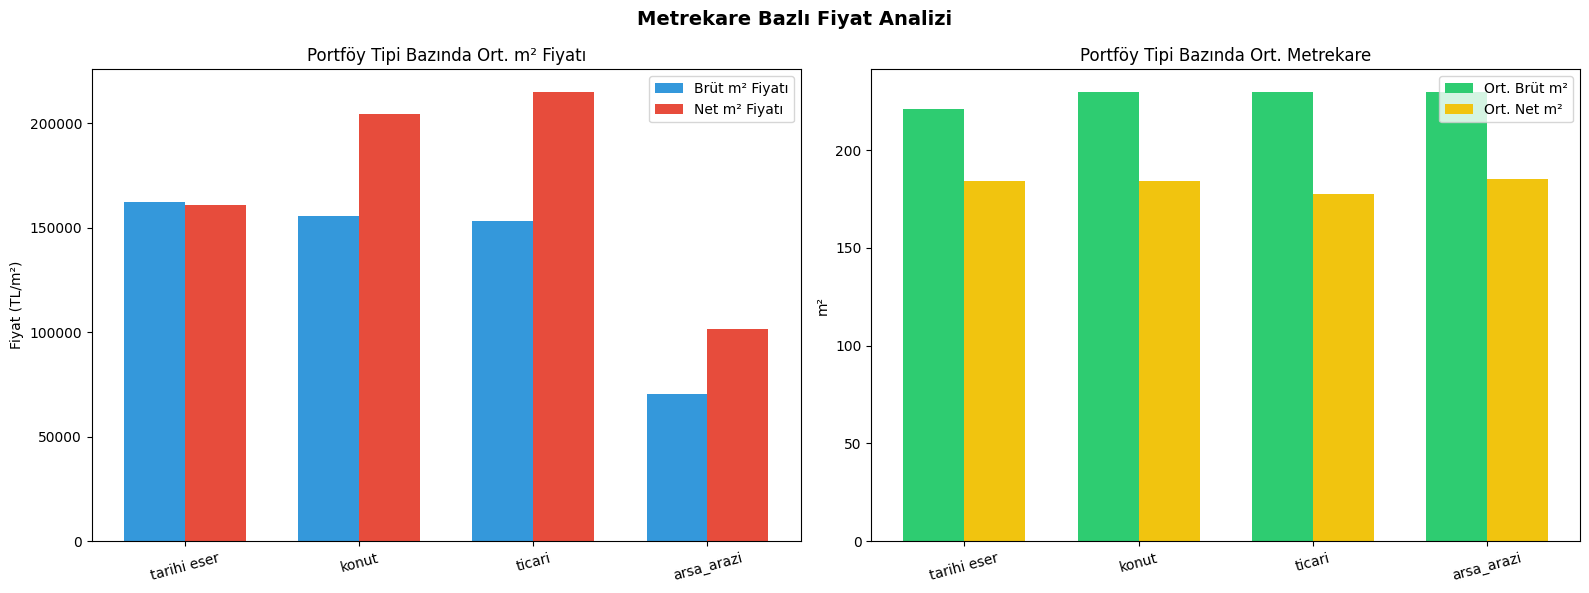

,portfoy_tipi,portfoy_sayisi,ort_brut_m2_fiyat_try,ort_net_m2_fiyat_try,ort_brut_m2,ort_net_m2,ort_liste_fiyati_try
0,tarihi eser,506,162314.88,160987.74,221.0,184.1,26485893.28
1,konut,6313,155668.85,204214.24,229.5,184.3,27928274.67
2,ticari,1053,153199.84,214972.89,229.7,177.5,27520543.21
3,arsa_arazi,737,70396.95,101623.13,229.8,185.4,14290697.42


In [79]:
with open("sql/Diger_Analizler/16_metrekare_bazli_fiyat.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_m2 = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(df_m2))
width = 0.35
axes[0].bar([i - width/2 for i in x], df_m2["ort_brut_m2_fiyat_try"], width, label="Brüt m² Fiyatı", color="#3498db")
axes[0].bar([i + width/2 for i in x], df_m2["ort_net_m2_fiyat_try"], width, label="Net m² Fiyatı", color="#e74c3c")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_m2["portfoy_tipi"], rotation=15)
axes[0].set_title("Portföy Tipi Bazında Ort. m² Fiyatı")
axes[0].set_ylabel("Fiyat (TL/m²)")
axes[0].legend()

axes[1].bar([i - width/2 for i in x], df_m2["ort_brut_m2"], width, label="Ort. Brüt m²", color="#2ecc71")
axes[1].bar([i + width/2 for i in x], df_m2["ort_net_m2"], width, label="Ort. Net m²", color="#f1c40f")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_m2["portfoy_tipi"], rotation=15)
axes[1].set_title("Portföy Tipi Bazında Ort. Metrekare")
axes[1].set_ylabel("m²")
axes[1].legend()

plt.suptitle("Metrekare Bazlı Fiyat Analizi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_m2

**Yorum:**

Bu analizde dikkat çeken bazı fiyat anomalileri ve portföy tipi karakteristikleri var.

Portföy Dağılımı:

Konut kategorisi 6.313 portföy ile toplamın %73.3'ünü oluşturuyor. Bu dominans, diğer tipleri karşılaştırmak için yeterli örneklem büyüklüğü sağlamıyor — özellikle tarihi eser (506) ve arsa/arazi (737) için yorumlar daha geniş güven aralıklarıyla değerlendirilmeli.

M2 Fiyat Sıralaması — Beklenen mi?

| Portföy Tipi | Brüt M2 Fiyatı (TL) |
|---------------|---------------------|
| Tarihi Eser   | 162.314             |
| Konut         | 155.668             |
| Ticari        | 153.199             |
| Arsa/Arazi    | 70.396              |

Tarihi eserin en yüksek m2 fiyatına sahip olması mantıklı. Koruma altındaki yapıların arzı sınırlı ve lokasyonları genellikle merkezi. Arsa/arazinin en düşük brüt m2 fiyatı da beklenen bir sonuç; bu kategoride m2 başı fiyat düşük ama toplam yüzey alanı büyük olur.

Kritik Anomali — Tarihi Eser: Brüt M2 Fiyatı > Net M2 Fiyatı:

Matematiksel olarak her mülk için net_m2 < brüt_m2 olduğundan, fiyat/net_m2 > fiyat/brüt_m2 olması zorunludur.

| Portföy Tipi  | Brüt M2 Fiyatı | Net M2 Fiyatı         |
|---------------|----------------|----------------------|
| Tarihi Eser   | 162.314        | 160.987 ← Düşük!     |
| Konut         | 155.668        | 204.214 ✓            |
| Ticari        | 153.199        | 214.972 ✓            |
| Arsa/Arazi    | 70.396         | 101.623 ✓            |

Konut, ticari ve arsa/arazi için net m2 fiyatı > brüt m2 fiyatı — bu doğru. Ancak tarihi eser'de brüt m2 fiyatı daha yüksek çıkıyor. Bu, bazı tarihi eser kayıtlarında net_m2 > brüt_m2 girildiğini gösteriyor. Fiziksel olarak imkânsız bir durum ve açık bir veri kalitesi sorunu.

Net M2 Değerleri Çarpıcı Biçimde Benzer:

| Portföy Tipi  | Ort. Net M2 |
|---------------|-------------|
| Tarihi Eser   | 184.1       |
| Konut         | 184.3       |
| Arsa/Arazi    | 185.4       |
| Ticari        | 177.5       |

Birbirinden tamamen farklı mülk tipleri için net m2 değerleri bu denli yakın — yine sentetik veri üretiminde tek bir dağılımın kullanıldığının işareti.

Operasyonel Çıkarım:

Tarihi eser portföyünün en yüksek m2 fiyatına rağmen net m2 alanının konut ile neredeyse aynı olması, bu segmentin fiyatlandırma mantığının ya henüz oturmadığını ya da veri girişinin tutarsız yapıldığını gösteriyor. Tarihi eser portföylerinde brüt_m2 ve net_m2 alan bilgilerinin doğruluğu kontrol edilmeli; bu veriler kira/satış fiyatı belirlemede kritik rol oynuyor.

17. ### Referral ve Cooperation Etkisi Analizi

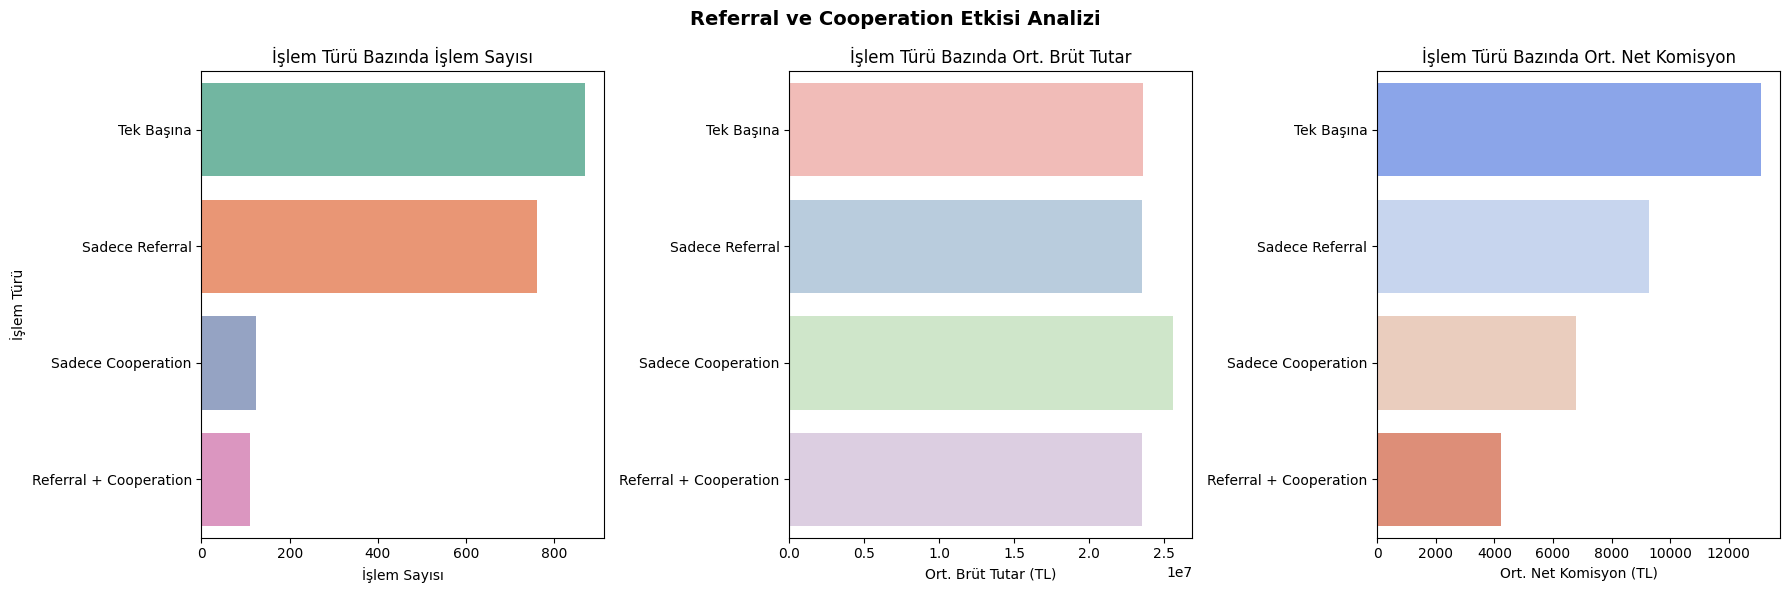

,islem_turu,islem_sayisi,ort_brut_tutar,toplam_brut_ciro_try,ort_komisyon_orani,ort_net_komisyon
0,Tek Başına,870,23610141.38,2.054082e+10,0.0556,13091.38
1,Sadece Referral,760,23524507.89,1.787863e+10,0.0497,9264.20
2,Sadece Cooperation,123,25596813.01,3.148408e+09,0.0555,6769.08
3,Referral + Cooperation,109,23559009.17,2.567932e+09,0.0506,4233.07


In [82]:
with open("sql/Diger_Analizler/17_referral_cooperation_etkisi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ref_coop = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=df_ref_coop, x="islem_sayisi", y="islem_turu", hue="islem_turu", palette="Set2", legend=False, ax=axes[0], errorbar=None)
axes[0].set_title("İşlem Türü Bazında İşlem Sayısı")
axes[0].set_xlabel("İşlem Sayısı")
axes[0].set_ylabel("İşlem Türü")

sns.barplot(data=df_ref_coop, x="ort_brut_tutar", y="islem_turu", hue="islem_turu", palette="Pastel1", legend=False, ax=axes[1], errorbar=None)
axes[1].set_title("İşlem Türü Bazında Ort. Brüt Tutar")
axes[1].set_xlabel("Ort. Brüt Tutar (TL)")
axes[1].set_ylabel("")

sns.barplot(data=df_ref_coop, x="ort_net_komisyon", y="islem_turu", hue="islem_turu", palette="coolwarm", legend=False, ax=axes[2], errorbar=None)
axes[2].set_title("İşlem Türü Bazında Ort. Net Komisyon")
axes[2].set_xlabel("Ort. Net Komisyon (TL)")
axes[2].set_ylabel("")

plt.suptitle("Referral ve Cooperation Etkisi Analizi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_ref_coop

**Yorum:** 

Ana Bulgu:

İşlem Türü	Ort. Net Komisyon	Fark
Tek Başına	13.091 TL	—
Sadece Referral	9.264 TL	-%29
Sadece Cooperation	6.769 TL	-%48
Referral + Cooperation	4.233 TL	-%68

Hem referral hem cooperation olan bir işlemde danışman, tek başına çalıştığı duruma göre 3 katı daha az net komisyon elde ediyor. Bu, aynı emeği harcayıp çok daha düşük getiri anlamına geliyor.

Cooperation Paradoksu:

Sadece Cooperation türünde ortalama brüt işlem tutarı 25.6M TL — tüm gruplar içinde en yüksek. Yani cooperation işlemleri daha değerli mülkleri kapsıyor. Ama getirilen net komisyon sadece 6.769 TL — tek başına çalışmanın yarısından az. Yüksek değerli işlemde çalışan danışman, gelirden en az payı alıyor.

Komisyon Oranı Örüntüsü:

| İşlem Türü             | Ort. Komisyon Oranı |
|------------------------|-------------------|
| Tek Başına             | %5.56             |
| Sadece Cooperation     | %5.55             |
| Referral + Cooperation | %5.06             |
| Sadece Referral        | %4.97             |

Komisyon oranları görece yakın (%4.97 - %5.56 arası), ancak net komisyon bu kadar dramatik farklılaşıyor. Bunun nedeni, "net komisyon" hesaplanırken referral ve cooperation ödemelerinin brüt komisyondan düşülmesi. Yani oran benzer, ama pay paylaşımından sonra kalan miktar ciddi düşüyor.

İşlem Dağılımı:

| İşlem Türü             | İşlem Sayısı | Yüzde  |
|------------------------|--------------|--------|
| Tek Başına             | 870          | %46.7  |
| Sadece Referral        | 760          | %40.8  |
| Referral + Cooperation | 109          | %5.9   |
| Sadece Cooperation     | 123          | %6.6   |

Neredeyse işlemlerin yarısı referral içeriyor (760 + 109 = 869 işlem). Bu, şirketin referral ağına ne denli bağımlı olduğunu gösteriyor.

Operasyonel Çıkarım:

Referral ve cooperation modelleri lead kalitesini ve portföy erişimini artırıyor olabilir, ancak danışman gelirini önemli ölçüde aşındırıyor. Şirketin şu soruyu cevaplaması gerekiyor: Referral/cooperation maliyeti, getirdiği ek işlem hacmini haklı kılıyor mu? Ayrıca cooperation işlemlerindeki bu yüksek mülk değeri + düşük komisyon oranı, cooperasyon partner seçimi ve sözleşme koşullarının yeniden değerlendirilmesi gerektiğine işaret ediyor.

18. ### Ürün/Eğitim Tamamlama ve Performansa Etkisi

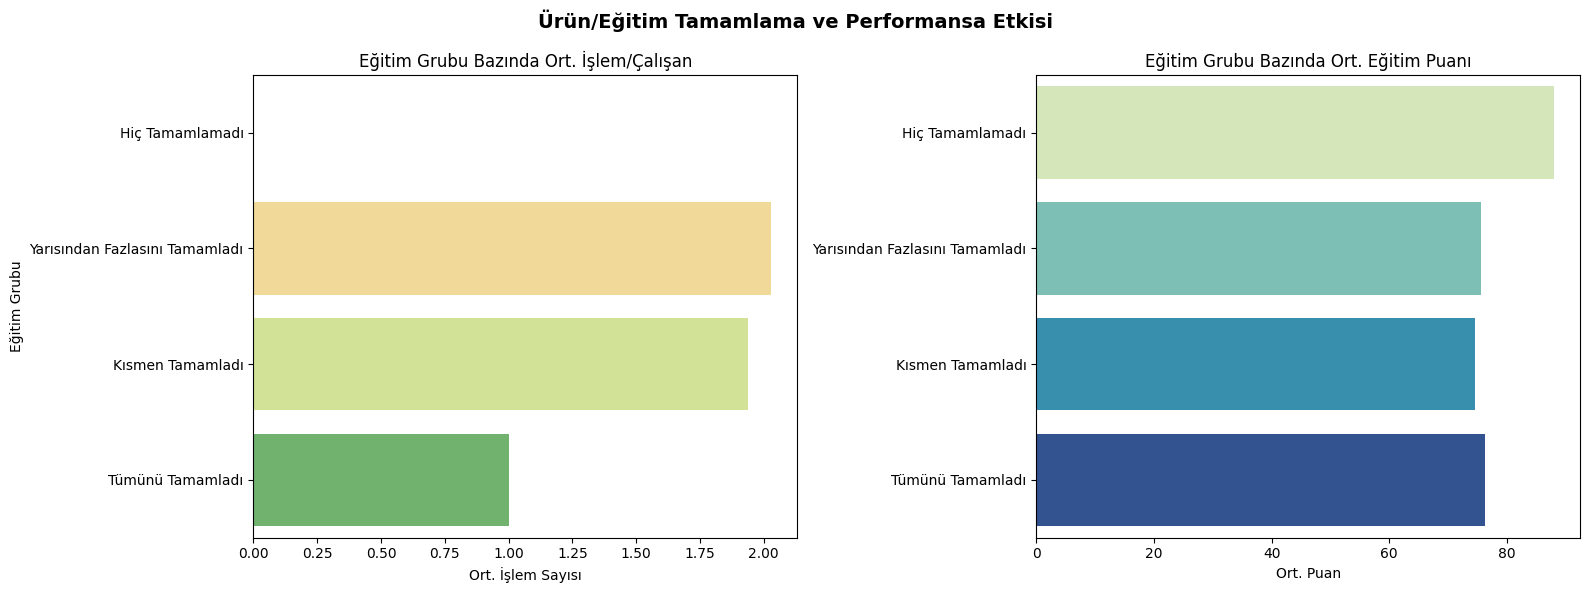

,egitim_grubu,calisan_sayisi,ort_egitim_puani,toplam_islem,ort_islem_per_calisan,ort_ciro_per_calisan
0,Hiç Tamamlamadı,2,88.00,0.0,NaN,NaN
1,Yarısından Fazlasını Tamamladı,1337,75.56,1768.0,2.03,21650693.10
2,Kısmen Tamamladı,61,74.49,66.0,1.94,21143294.12
3,Tümünü Tamamladı,400,76.28,28.0,1.00,11015892.86


In [83]:
with open("sql/Diger_Analizler/18_urun_egitim_performans.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_egitim = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_egitim, x="ort_islem_per_calisan", y="egitim_grubu", hue="egitim_grubu", palette="RdYlGn", legend=False, ax=axes[0], errorbar=None)
axes[0].set_title("Eğitim Grubu Bazında Ort. İşlem/Çalışan")
axes[0].set_xlabel("Ort. İşlem Sayısı")
axes[0].set_ylabel("Eğitim Grubu")

sns.barplot(data=df_egitim, x="ort_egitim_puani", y="egitim_grubu", hue="egitim_grubu", palette="YlGnBu", legend=False, ax=axes[1], errorbar=None)
axes[1].set_title("Eğitim Grubu Bazında Ort. Eğitim Puanı")
axes[1].set_xlabel("Ort. Puan")
axes[1].set_ylabel("")

plt.suptitle("Ürün/Eğitim Tamamlama ve Performansa Etkisi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_egitim

**Yorum:** 

Ana Paradoks — Eğitimi Tamamlayanlar En Az Satıyor:

| Eğitim Grubu                  | Ort. İşlem/Kişi | Ort. Ciro/Kişi |
|-------------------------------|----------------|----------------|
| Yarısından Fazlasını Tamamladı | 2.03           | 21.65M TL      |
| Kısmen Tamamladı               | 1.94           | 21.14M TL      |
| Tümünü Tamamladı               | 1.00           | 11.02M TL      |
| Hiç Tamamlamadı                | NaN            | NaN            |

Eğitimi tam olarak bitiren grup hem işlem sayısında hem ciroda en alt sırada. Bu beklentinin tam tersi.

İki Olası Açıklama:

1. Yeni Çalışan Hipotezi (En Güçlü): "Tümünü Tamamladı" grubunun yeni/junior çalışanlardan oluşması kuvvetle muhtemel. Yeni işe başlayan birinin tüm onboarding eğitimlerini tamamlaması doğal, ancak henüz aktif müşteri portföyü veya satış deneyimi yok. Bu durumda eğitim tamamlama, deneyim eksikliğinin göstergesi olur — eğitimin kendisi sorumlu değil.

2. Sahaya Zaman Ayıramama: Eğitim yükümlülüğü yüksek olan çalışanların müşteri ziyareti, portföy takibi gibi gelir üretici aktivitelere daha az zaman ayırıyor olması mümkün. Eğitim içeriği ve yoğunluğu satış verimliliğiyle dengelenmeli.

Eğitim Puanı Anomalisi:

"Hiç Tamamlamadı" grubunun eğitim puanı 88.00 — en yüksek puan. Ama bu grup sadece 2 kişiden oluşuyor, istatistiksel olarak anlamsız. Yine de eğitim puanı ile tamamlama oranının birbirinden bağımsız ölçütler olduğuna dikkat çekiyor — biri öğrenme kalitesini, diğeri tamamlanma sayısını ölçüyor.

"Kısmen" ve "Yarısından Fazla" Grupları Neredeyse Aynı:

| Eğitim Durumu           | Ort. İşlem | Ort. Ciro  |
|-------------------------|------------|------------|
| Kısmen Tamamladı        | 1.94       | 21.14M     |
| Yarısından Fazlasını    | 2.03       | 21.65M     |


%5'lik fark istatistiksel olarak anlamsız. Bu iki grup pratikte aynı performansı sergiliyor — sahada eğitim yüzdesinin belirli bir eşiğin üzerinde olması fark yaratmıyor.

Operasyonel Çıkarım:

Eğitim programının satış performansına doğrudan pozitif katkı sağladığı bu veriden desteklenemiyor. Şirketin eğitim yatırımının geri dönüşünü ölçmek için:

Eğitim tamamlama tarihi ile ilk satış tarihi arasındaki süreyi izlemesi
Çalışan kıdemiyle eğitim durumunu birlikte analiz etmesi
"Tümünü Tamamladı" grubunun ne kadar süredir çalıştığını kontrol etmesi gerekiyor

19. ### Pazarlama CTR (Tıklama/Gösterim Oranı) Analizi

In [98]:
with open("sql/Diger_Analizler/19_pazarlama_ctr_analizi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_ctr = pd.read_sql(query, engine)



df_ctr

,kanal,kampanya_sayisi,toplam_gosterim,toplam_tiklama,toplam_lead,ctr_pct,tiklama_to_lead_pct,lead_basi_maliyet_try
0,email,856,62163577,5048014,59961,8.12,1.19,579.39
1,youtube,855,62056626,4977269,60384,8.02,1.21,604.55
2,afis_branda,855,62116707,4952308,59679,7.97,1.21,908.01
3,emlakjet,856,62235315,4954572,60078,7.96,1.21,594.15
4,sahibinden,856,62258557,4939727,60222,7.93,1.22,593.66
5,meta_ads,856,62137134,4919170,60033,7.92,1.22,593.36
6,social_media,855,62126715,4897984,60132,7.88,1.23,593.23
7,google_ads,856,62076956,4882377,60333,7.87,1.24,588.43
8,tiktok_ads,855,62146545,4875839,60168,7.85,1.23,589.54
9,hepsiemlak,856,62171936,4854798,60225,7.81,1.24,977.67


**Yorum:** 

| Metrik          | Aralık              |
|-----------------|-------------------|
| Kampanya Sayısı  | 855 - 856         |
| Toplam Gösterim  | 62.05M - 62.26M   |
| Toplam Lead      | 59.679 - 60.489   |
| CTR              | %7.76 - %8.12     |
| Tıklama → Lead   | %1.19 - %1.25     |

Tamamen farklı mekanizmayla çalışan 11 kanalın gösterim, tıklama ve lead sayıları bu kadar dar bir bantta kümelenmesi gerçek hayatta imkânsız. Tüm değerler neredeyse özdeş — güçlü sentetik dağılım sinyali.

Kanal Bazlı CTR Anomalileri:

Gerçek benchmark değerleriyle karşılaştırıldığında tablodaki oranlar ciddi biçimde sapıyor:

| Kanal        | Tablodaki CTR |
|--------------|---------------|
| Email        | %8.12         |
| YouTube      | %8.02         |
| Google Ads   | %7.87         |
| Meta Ads     | %7.92         |
| TikTok Ads   | %7.85         |

En Kritik Anomali — Afis/Branda Kanalı:
Fiziksel afiş ve branda için "tıklama" verisi pratikte ölçülemez. Bu kanalda 4.952.308 tıklama kaydı görünüyor. Bu ya:

QR kod taramalarının "tıklama" olarak sayılmasını (bu durumda kanalın tanımı netleştirilmeli),
Ya da dummy veri üretiminde kanal özelliklerinin hiç gözetilmediğini gösteriyor.

Lead Başı Maliyet Sıralaması:

| Kanal        | Lead Başı Maliyet (TL)   |
|--------------|-------------------------|
| email          | 579.39 (en ucuz)        |
| SMS   | 582.26                  |
| Google Ads   | 588.43                 |
| hepsiemlak   | 977.67 (en pahalı)      |


Operasyonel Çıkarım:

Gerçek veriye dayalı bir pazarlama mix analizi yapılsaydı şu sorular kritik önem taşırdı:

Afis/Branda gibi brand awareness kanallarının lead maliyetiyle ölçülmesi doğru mu, yoksa farklı bir KPI'a mı bakılmalı?
SMS/email'in düşük maliyeti kapasite kısıtı mı yansıtıyor (limit sayıda kişiye gönderilebiliyor) yoksa gerçekten verimli mi?

20. ### Portföy Durumu Geçiş Süresi Analizi

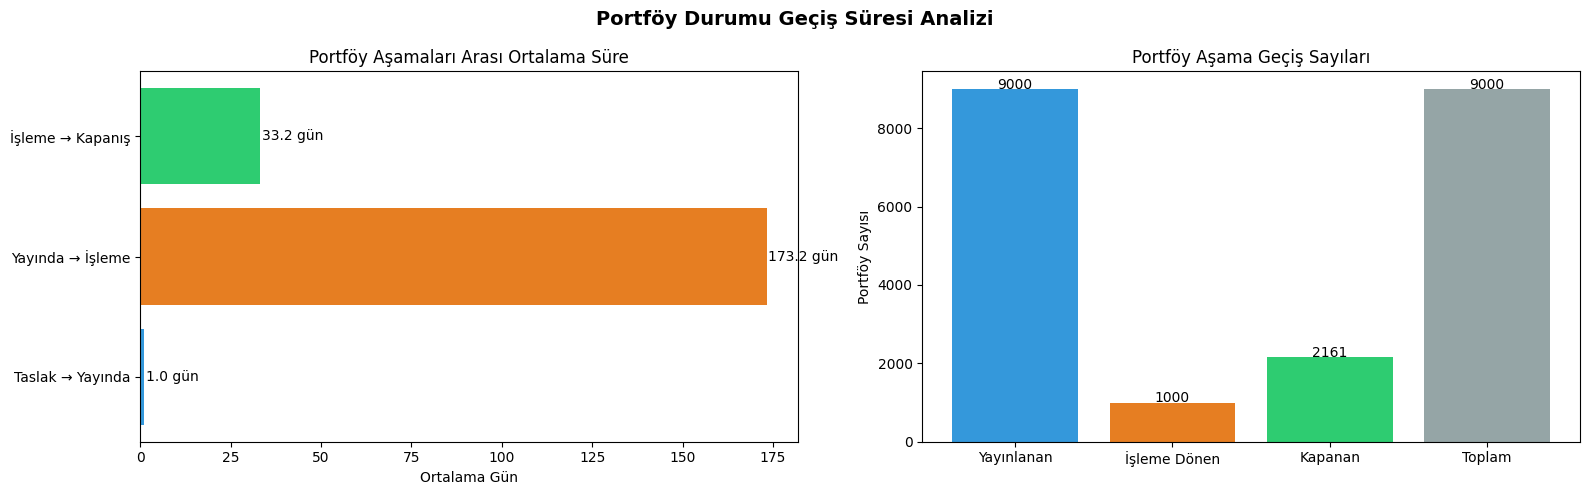

,taslak_to_yayinda_gun,yayinda_to_isleme_gun,isleme_to_kapanis_gun,toplam_surec_gun,yayinlanan,isleme_donusen,kapanan,toplam_portfoy
0,1.0,173.2,33.2,184.8,9000,1000,2161,9000


In [99]:
with open("sql/Diger_Analizler/20_portfoy_gecis_suresi.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_gecis = pd.read_sql(query, engine)

stages = ["taslak_to_yayinda_gun", "yayinda_to_isleme_gun", "isleme_to_kapanis_gun"]
labels = ["Taslak → Yayında", "Yayında → İşleme", "İşleme → Kapanış"]
values = [float(df_gecis[col].iloc[0]) if pd.notna(df_gecis[col].iloc[0]) else 0 for col in stages]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#3498db", "#e67e22", "#2ecc71"]
axes[0].barh(labels, values, color=colors)
axes[0].set_xlabel("Ortalama Gün")
axes[0].set_title("Portföy Aşamaları Arası Ortalama Süre")
for i, v in enumerate(values):
    axes[0].text(v + 0.5, i, f"{v:.1f} gün", va="center")

counts_labels = ["Yayınlanan", "İşleme Dönen", "Kapanan", "Toplam"]
counts_cols = ["yayinlanan", "isleme_donusen", "kapanan", "toplam_portfoy"]
counts_values = [int(df_gecis[col].iloc[0]) for col in counts_cols]
bar_colors = ["#3498db", "#e67e22", "#2ecc71", "#95a5a6"]
axes[1].bar(counts_labels, counts_values, color=bar_colors)
axes[1].set_ylabel("Portföy Sayısı")
axes[1].set_title("Portföy Aşama Geçiş Sayıları")
for i, v in enumerate(counts_values):
    axes[1].text(i, v + 5, str(v), ha="center")

plt.suptitle("Portföy Durumu Geçiş Süresi Analizi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_gecis

**Yorum:** 

Portföy Huni Dağılımı:

| Aşama           | Sayı  | Oran  |
|-----------------|------|------|
| Toplam Portföy  | 9.000 | %100 |
| Yayınlanan      | 9.000 | %100 |
| İşleme Dönen    | 1.000 | %11.1 |
| Kapanan         | 2.161 | %24  |

9.000 portföyün yalnızca %11.1'i işlem sürecine giriyor. Kapanan 2.161 portföyün işleme dönen 1.000'den fazla olması, bir kısmının işleme girmeksizin doğrudan kapandığını (iptal, süresi dolma, vazgeçme) gösteriyor.

Süreç Aşamalarının Analizi:

| Aşama              | Süre        |
|-------------------|------------|
| Taslak → Yayında   | 1.0 gün    |
| Yayında → İşleme   | 173.2 gün  |
| İşleme → Kapanış   | 33.2 gün   |
| Toplam Süreç       | 184.8 gün  |

Taslak → Yayın: 1 gün — Operasyonel açıdan son derece verimli. Portföylerin neredeyse anında yayınlanması iyi bir ilan yönetimi sürecine işaret ediyor. Ancak dummy veride bu aşamanın bilerek kısa tutulmuş olma ihtimali de var.

Yayında → İşleme: 173.2 gün (~5.7 ay) — Toplam sürecin %93.7'si bu aşamada geçiyor. Portföy yayınlandıktan sonra bir alıcı/kiracı bulunana kadar geçen süre bu kadar uzunsa, piyasada ciddi bir likidite sorunu var demektir. Bu süre hem fiyatlandırma hatalarına hem de pazarlama etkinliğine ilişkin soru işaretleri doğuruyor.

İşleme → Kapanış: 33.2 gün (~1 ay) — İşlem başladıktan sonra süreç görece hızlı tamamlanıyor. Hukuki ve idari süreçlerin yönetimi iyi çalışıyor.

Toplam Süreç Tutarsızlığı:

1.0 + 173.2 + 33.2 = 207.4 gün, ancak toplam_surec_gun = 184.8 gün. Bu fark, her aşama ortalamasının farklı portföy alt kümelerinden hesaplanmasından kaynaklanıyor — örneğin, taslak→yayın süresine sahip portföyler ile işleme→kapanış verisi olanlar farklı gruplar. Bu matematiksel tutarsızlık beklenen ve normal bir agregasyon davranışı.

Operasyonel Çıkarım:

Sürecin darboğazı %93.7 ağırlıkla "Yayında kalma süresi". Şirketin bu süreyi kısaltmak için:

Fiyat belirleme danışmanlığı: Portföylerin gerçekçi fiyatlarla yayına çıkması satış süresini doğrudan etkiler
Aktif portföy takibi: 90 gün üzerinde satılmayan portföyler için yeniden fiyatlama veya pazarlama müdahalesi
Lead-portföy eşleştirme kalitesi: Doğru alıcı/kiracıya ulaşma hızını artıracak segmentasyon
%11.1 işleme dönüşüm oranı ile daha önce gördüğümüz %20-21 satış oranları arasındaki fark da dikkat çekici — tanım farklılıklarından kaynaklanıyor olabilir, ancak bu tutarsızlığın veri modelinde netleştirilmesi gerekiyor.

21. ### Randevu Tipi Bazında Satış Dönüşüm Oranı

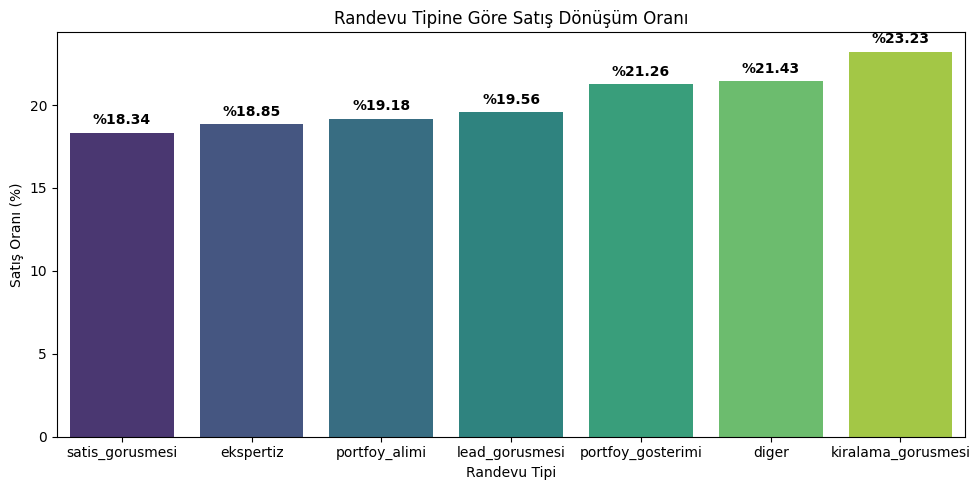

In [100]:
with open("sql/Portfoy_Analizi/randevu_satis_donusum_orani.sql", "r", encoding="utf-8") as f:
    query = f.read()
df_randevu_don = pd.read_sql(query, engine)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_randevu_don, x="randevu_tipi", y="satis_orani_yuzde",
            hue="randevu_tipi", palette="viridis", legend=False)
for i, row in df_randevu_don.iterrows():
    plt.text(i, row["satis_orani_yuzde"] + 0.5,
             f"%{row['satis_orani_yuzde']}", ha="center", fontweight="bold")
plt.xlabel("Randevu Tipi")
plt.ylabel("Satış Oranı (%)")
plt.title("Randevu Tipine Göre Satış Dönüşüm Oranı")
plt.tight_layout()
plt.show()

**Yorum:** Randevu tiplerine göre satış dönüşüm oranlarında kısmi farklılıklar bulunmaktadır. Yüksek dönüşüm oranına sahip randevu tipleri, satış sürecinde daha etkili olduğunu göstermektedir. Bu veri, danışmanların hangi tür randevulara odaklanması gerektiği ve randevu stratejilerinin nasıl optimize edilebileceği konusunda değerli bir içgörü sunabilir. Öbür yandan, Örneğin kiralama görüşmesinin satışa dönüşme olasılığı daha yüksek olduğundan buradaki oranlar bu beklentiye uygun çıkmıştır.

# Final Olarak

Bazı kayıtlarda işlem tarihi portföy oluşturulma tarihinden önce göründüğü için veri kalitesi problemi tespit edildi. Bu nedenle analiz yapılırken tarih tutarlılığı filtrelenmiştir. Ayrıca belirli verilerde değişkenin değer dağılımları sabitlenmiştir.

Belirli case'ler için Makine Öğrenmesi modelleri kurularak sonuç önceden tahmin edilmeye çalışılabilir. Örn : bu özelliklerdeki lead randevu/portföy/satış 'a dönüşecek mi? olasılığı ne? gibi ve benzer konularda çalışmalar yapılabilir.

Veri Dummy olmasına rağmen uğraşmaktan keyif aldığım bir deneyim oldu. Umarım gerçeğiyle de çalışma fırsatı bulabilirim.

Kodları tekrar çalıştırmak veya incelemek için : 


